## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import random
import yaml

## 2. Configuration and Character Set

In [2]:
# Device configuration
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Load characters from the exported model's config
with open('exported_model/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

characters = config['character']
char2idx = {char: i + 1 for i, char in enumerate(characters)} # 0 is blank
idx2char = {i + 1: char for i, char in enumerate(characters)}

n_chars = len(characters)
print(f'Number of characters: {n_chars}')
print(f'Characters: "{characters}"')

Using device: mps
Number of characters: 140
Characters: " !"()-./0123456789:=?ABCDEFGHIKLMNOPQRSTUWYabcdefghijklmnoprstuvwyँंअआइईउऊऎएऒओऔकखगघङचछजझञटठडढणतथदधनपफबभमयरलवशषसहािीुूृॄॅॆेैॉॊोौ्फ़।०१२३४५६७८९"


## 3. CRNN Model

In [3]:
class CRNN(nn.Module):
    def __init__(self, n_class=n_chars + 1):
        super().__init__()

        # --- CNN --- (VGG-style)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2), # 64x32
            nn.Conv2d(64, 128, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2), # 128x16
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(True), # 256x16
            nn.Conv2d(256, 256, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 1), (2, 1)), # 256x8
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True), # 512x8
            nn.Conv2d(512, 512, 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2, 1), (2, 1)), # 512x4
            nn.Conv2d(512, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(True) # 512x4
        )

        # --- Map-to-Sequence --- 
        self.map2seq = nn.Linear(512 * 4, 256)

        # --- RNN --- 
        self.rnn = nn.LSTM(256, 256, num_layers=2, bidirectional=True)
        
        # --- Fully Connected --- 
        self.fc = nn.Linear(512, n_class)

    def forward(self, x):
        # CNN part
        conv = self.cnn(x) # [B, C, H, W]
        
        # Map-to-Sequence part
        B, C, H, W = conv.size()
        conv = conv.permute(0, 3, 1, 2) # [B, W, C, H]
        conv = conv.reshape(B, W, C * H) # [B, W, C*H]
        seq = self.map2seq(conv) # [B, W, 256]
        
        # RNN part
        seq = seq.permute(1, 0, 2) # [W, B, 256]
        recurrent, _ = self.rnn(seq) # [W, B, 512]
        
        # FC part
        output = self.fc(recurrent) # [W, B, n_class]
        return output

print('CRNN model definition is ready.')

CRNN model definition is ready.


## 4. Dataset and Data Loading

In [ ]:
IMG_HEIGHT = 64 # Match config.yaml imgH

class NepaliWordDataset(Dataset):
    def __init__(self, label_file, img_dir, char2idx, img_height=IMG_HEIGHT):
        self.img_dir = img_dir
        self.char2idx = char2idx
        self.img_height = img_height
        
        # Load and filter labels
        df = pd.read_csv(label_file, sep='\\t', header=None, names=['filename', 'label'], engine='python')
        df.dropna(inplace=True)
        df = df[df['label'].str.len() > 0]
        
        self.samples = []
        for _, row in df.iterrows():
            filepath = os.path.join(self.img_dir, row['filename'])
            if os.path.exists(filepath):
                self.samples.append((filepath, row['label']))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        try:
            image = Image.open(img_path).convert('L') # Grayscale
        except (IOError, OSError):
            # Handle corrupted images by returning a dummy sample
            print(f"Warning: Could not read image {img_path}. Skipping.")
            return self.__getitem__((idx + 1) % len(self))

        # Resize and normalize
        w, h = image.size
        new_w = int(w * (self.img_height / h))
        image = image.resize((new_w, self.img_height), Image.BICUBIC)
        
        # Encode label
        label_encoded = torch.tensor([self.char2idx[c] for c in label if c in self.char2idx], dtype=torch.long)
        
        return image, label_encoded

# Augmentation transforms
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=5, fill=255),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5, fill=255),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.01, 0.05), ratio=(0.3, 3.3)),
    transforms.Normalize((0.5,), (0.5,)),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

class TransformedSubset(Dataset):
    def __init__(self, subset, indices, transform):
        self.subset = subset
        self.indices = indices if indices is not None else list(range(len(subset)))
        self.transform = transform
        
    def __getitem__(self, idx):
        original_idx = self.indices[idx]
        img, label = self.subset[original_idx]
        return self.transform(img), label

    def __len__(self):
        return len(self.indices)

# --- Main Dataset ---
base_dataset = NepaliWordDataset(
    label_file='all_data.tsv',
    img_dir='all_images',
    char2idx=char2idx
)
print(f'Found {len(base_dataset)} total samples.')

In [ ]:
# --- Data split and loaders ---
BATCH_SIZE = 16  # Reduced for MPS memory
MAX_IMG_WIDTH = 600  # Cap width to prevent OOM on wide images

n_total = len(base_dataset.samples)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

indices = list(range(n_total))
import random
random.seed(42)
random.shuffle(indices)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# Separate transforms for train (augmented) vs val (clean)
train_dataset = TransformedSubset(base_dataset, train_indices, train_transform)
val_dataset = TransformedSubset(base_dataset, val_indices, val_transform)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')


def collate_fn(batch):
    imgs, labels_encoded = zip(*batch)

    # Cap width to prevent OOM
    capped_imgs = []
    for img in imgs:
        if img.size(2) > MAX_IMG_WIDTH:
            img = img[:, :, :MAX_IMG_WIDTH]
        capped_imgs.append(img)

    max_w = max(img.size(2) for img in capped_imgs)

    padded_images = []
    for img in capped_imgs:
        pad_w = max_w - img.size(2)
        padded = F.pad(img, (0, pad_w), value=1.0)
        padded_images.append(padded)

    imgs = torch.stack(padded_images)
    label_lens = torch.tensor([len(l) for l in labels_encoded], dtype=torch.long)
    labels = torch.cat(labels_encoded)
    return imgs, labels, label_lens


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# Quick check
imgs, labs, lens = next(iter(train_loader))
print(f'Batch images: {imgs.shape}, labels: {labs.shape}, label_lengths: {lens.shape}')
print(f'Padding value check — rightmost pixel mean: {imgs[0, 0, :, -1].mean().item():.3f} (expect ~1.0)')

## 5. Greedy CTC Decoder

In [4]:
def greedy_decoder(output):
    """Decode CTC output. output shape: [T, B, C]"""
    output = output.softmax(2)
    max_indices = output.argmax(2).permute(1, 0)  # [B, T]
    decoded = []
    for indices in max_indices:
        s = ''
        prev = 0
        for i in indices:
            idx = i.item()
            if idx != prev and idx != 0:  # skip blank and repeats
                if idx in idx2char:
                    s += idx2char[idx]
            prev = idx
        decoded.append(s)
    return decoded

print('Decoder ready.')

Decoder ready.


## 6. Training

In [ ]:
model = CRNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

EPOCHS = 100
SAVE_PATH = 'exported_model/nepali_crnn_best.pth'
ACCUM_STEPS = 2  # Gradient accumulation to simulate batch_size=32

best_val_loss = float('inf')
train_losses = []
val_losses = []
patience_counter = 0
EARLY_STOP_PATIENCE = 20

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    for step, (imgs, labels, label_lengths) in enumerate(train_loader):
        imgs = imgs.to(device)

        preds = model(imgs)  # [T, B, C]
        preds_log = preds.log_softmax(2).cpu()

        input_lengths = torch.full(
            size=(imgs.size(0),),
            fill_value=preds.size(0),
            dtype=torch.long,
        )

        loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
        loss = loss / ACCUM_STEPS
        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUM_STEPS

        # Clear MPS cache periodically
        if step % 500 == 0 and device.type == 'mps':
            torch.mps.empty_cache()

    avg_train = total_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- Validate ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for imgs, labels, label_lengths in val_loader:
            imgs = imgs.to(device)

            preds = model(imgs)
            preds_log = preds.log_softmax(2).cpu()

            input_lengths = torch.full(
                size=(imgs.size(0),),
                fill_value=preds.size(0),
                dtype=torch.long,
            )

            loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
            total_val_loss += loss.item()

    if device.type == 'mps':
        torch.mps.empty_cache()

    avg_val = total_val_loss / len(val_loader)
    val_losses.append(avg_val)

    # LR scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val)
    new_lr = optimizer.param_groups[0]['lr']
    lr_msg = f' LR {old_lr:.1e}->{new_lr:.1e}' if new_lr != old_lr else ''

    # Save best + early stopping
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        patience_counter = 0
        marker = ' * saved'
    else:
        patience_counter += 1
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {new_lr:.1e}{marker}{lr_msg}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

In [ ]:
# Training summary
print(f'Epochs trained: {len(train_losses)}')
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final val loss: {val_losses[-1]:.4f}')
print(f'Last 5 epochs:')
for i in range(max(0, len(train_losses)-5), len(train_losses)):
    print(f'  Epoch {i+1}: train={train_losses[i]:.4f}, val={val_losses[i]:.4f}')

## 7. Loss Curves

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. Evaluate — Random Samples

In [ ]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print('Loaded best model for evaluation.')

# Get some random samples from validation set
val_subset_indices = random.sample(range(len(val_dataset)), k=16)
val_subset = torch.utils.data.Subset(val_dataset, val_subset_indices)
val_subset_loader = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# Plot predictions
with torch.no_grad():
    for imgs, labels, label_lengths in val_subset_loader:
        imgs_gpu = imgs.to(device)
        preds = model(imgs_gpu)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        decoded_gts = []
        start = 0
        for length in label_lengths:
            decoded_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        # Plot
        n_cols = 2
        n_rows = (len(imgs) + n_cols - 1) // n_cols
        plt.figure(figsize=(12, n_rows * 3))
        for i in range(len(imgs)):
            plt.subplot(n_rows, n_cols, i+1)
            plt.imshow(imgs[i].permute(1, 2, 0), cmap='gray')
            plt.title(f'GT:  {decoded_gts[i]}\nPred: {decoded_preds[i]}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

## 9. Evaluate — CER / WER Metrics

In [ ]:
!pip install jiwer -q

from jiwer import cer, wer
from tqdm.auto import tqdm

all_gts = []
all_preds = []

with torch.no_grad():
    for imgs, labels, label_lengths in tqdm(val_loader, desc='Evaluating on validation set'):
        imgs = imgs.to(device)
        preds = model(imgs)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        start = 0
        for length in label_lengths:
            all_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        all_preds.extend(decoded_preds)

# Calculate metrics
char_error_rate = cer(all_gts, all_preds)
word_error_rate = wer(all_gts, all_preds)

print(f'Validation CER: {char_error_rate:.4f}')
print(f'Validation WER: {word_error_rate:.4f}')

## 10. Evaluate on Test Set (`Dataset/crops`)

In [ ]:
# Create a dataset for the separate test set
test_label_file = 'Dataset/labels.csv'
test_img_dir = 'Dataset/crops'

# Check if the files exist
if not (os.path.exists(test_label_file) and os.path.exists(test_img_dir)):
    print("Test set files not found, skipping evaluation.")
else:
    test_base_dataset = NepaliWordDataset(
        label_file=test_label_file,
        img_dir=test_img_dir,
        char2idx=char2idx
    )
    test_dataset = TransformedSubset(test_base_dataset, indices=None, transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    print(f'Test samples: {len(test_dataset)}')

    # Evaluate on the test set
    test_gts = []
    test_preds = []
    model.eval()
    with torch.no_grad():
        for imgs, labels, label_lengths in tqdm(test_loader, desc='Evaluating on test set'):
            imgs = imgs.to(device)
            preds = model(imgs)
            decoded_preds = greedy_decoder(preds)

            # Decode ground truth labels
            start = 0
            for length in label_lengths:
                test_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
                start += length

            test_preds.extend(decoded_preds)

    # Calculate metrics
    test_cer = cer(test_gts, test_preds)
    test_wer = wer(test_gts, test_preds)

    print(f'Test Set CER: {test_cer:.4f}')
    print(f'Test Set WER: {test_wer:.4f}')

### Fixing Font Rendering for Devanagari

The plots above show blank squares instead of Nepali characters in the titles. This is a classic `matplotlib` issue where the default font does not contain the necessary glyphs for the Devanagari script.

To fix this, we need to find a font on the system that supports Devanagari and explicitly tell `matplotlib` to use it for the titles. On macOS, "Devanagari Sangam MN" is a good candidate. We'll use `font_manager` to apply this font.

In [ ]:
import matplotlib.font_manager as fm

# Find a font that supports Nepali characters
font_path = '/System/Library/Fonts/DevanagariSangamMN.ttc' # Common on macOS
if not os.path.exists(font_path):
    # Fallback for other systems - user might need to specify a path
    font_path = None
    print("Devanagari font not found at default macOS path. Titles may not render correctly.")
    print("Please specify the path to a .ttf or .ttc file with Devanagari support.")

font_prop = fm.FontProperties(fname=font_path) if font_path else None

# --- Re-plot with the correct font ---
with torch.no_grad():
    for imgs, labels, label_lengths in val_subset_loader:
        imgs_gpu = imgs.to(device)
        preds = model(imgs_gpu)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        decoded_gts = []
        start = 0
        for length in label_lengths:
            decoded_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        # Plot
        n_cols = 2
        n_rows = (len(imgs) + n_cols - 1) // n_cols
        plt.figure(figsize=(12, n_rows * 3))
        for i in range(len(imgs)):
            plt.subplot(n_rows, n_cols, i+1)
            plt.imshow(imgs[i].permute(1, 2, 0), cmap='gray')
            title_text = f'GT:  {decoded_gts[i]}\nPred: {decoded_preds[i]}'
            plt.title(title_text, fontproperties=font_prop) # Apply the font property
            plt.axis('off')
        plt.tight_layout()
        plt.show()

## 11. Error Analysis: Best and Worst Predictions

In [ ]:
# Get all predictions and calculate CER for each sample
results = []
model.eval()
with torch.no_grad():
    for i, (img_tensor, label_encoded) in enumerate(tqdm(val_dataset, desc="Analyzing validation set")):
        img_tensor_unsqueezed = img_tensor.unsqueeze(0)
        
        # Ground Truth
        gt = ''.join([idx2char[i.item()] for i in label_encoded])

        # Prediction
        img_gpu = img_tensor_unsqueezed.to(device)
        pred_raw = model(img_gpu)
        pred = greedy_decoder(pred_raw)[0]
        
        # CER
        error = cer(gt, pred)
        
        results.append({
            'image': img_tensor,
            'gt': gt,
            'pred': pred,
            'cer': error
        })

# Sort by CER
results.sort(key=lambda x: x['cer'])

print(f"Analyzed {len(results)} samples.")
print(f"Best CER: {results[0]['cer']:.4f}, Worst CER: {results[-1]['cer']:.4f}")

In [ ]:
def plot_results_grid(results_subset, title):
    n_cols = 4
    n_rows = (len(results_subset) + n_cols - 1) // n_cols
    plt.figure(figsize=(16, n_rows * 4))
    plt.suptitle(title, fontsize=20, y=1.02)
    for i, res in enumerate(results_subset):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(res['image'].permute(1, 2, 0), cmap='gray')
        title_text = f"GT: {res['gt']}\nPred: {res['pred']}\nCER: {res['cer']:.2f}"
        plt.title(title_text, fontproperties=font_prop)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot Best Predictions (Lowest CER)
plot_results_grid(results[:8], 'Best Predictions (Lowest CER)')

# Plot Worst Predictions (Highest CER)
plot_results_grid(results[-8:], 'Worst Predictions (Highest CER)')

### Refining "Worst" Predictions

The initial "worst predictions" plot is dominated by samples with very short or nonsensical ground truth labels (like `-` or ` (`). A high CER on a single-character label is often misleading. To get a more meaningful view of the model's failures on actual words, let's filter out samples where the ground truth is trivially short (e.g., 2 characters or fewer).

In [ ]:
# Filter out results with very short ground truth
MIN_GT_LEN = 3
meaningful_results = [res for res in results if len(res['gt']) >= MIN_GT_LEN]

# Re-sort by CER
meaningful_results.sort(key=lambda x: x['cer'])

print(f"Filtered from {len(results)} to {len(meaningful_results)} samples with GT >= {MIN_GT_LEN} chars.")

# Plot new worst predictions
plot_results_grid(meaningful_results[-8:], 'Worst Predictions (Meaningful GT)')

# Nepali HTR — CRNN Training Pipeline
 (VGG + BiLSTM + CTC), adapted for Nepali character set on YOLO-cropped word images.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

## 1. Character Set & Helpers

In [ ]:
# Read character set from file
CHAR_FILE = 'exported_model/nepali_char.txt'
with open(CHAR_FILE, 'r', encoding='utf-8') as f:
    CHARS = [line.rstrip('\n') for line in f]

# Index 0 is reserved for CTC blank, so chars are 1-indexed
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS) + 1  # +1 for CTC blank at index 0

print(f'Character set size: {len(CHARS)}')
print(f'Num classes (with blank): {NUM_CLASSES}')
print(f'First 10 chars: {CHARS[:10]}')
print(f'Nepali chars sample: {CHARS[70:90]}')


def text_to_labels(text):
    """Convert text to label indices. Raises on unknown characters."""
    labels = []
    for c in text:
        if c not in char2idx:
            raise ValueError(
                f'Character {repr(c)} (U+{ord(c):04X}) in label not found in charset. '
                f'Add it to {CHAR_FILE} or clean the label.'
            )
        labels.append(char2idx[c])
    return labels

## 2. Model Architecture (CRNN — same as anveshanout)

In [ ]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BidirectionalLSTM, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, input):
        try:
            self.rnn.flatten_parameters()
        except:
            pass
        recurrent, _ = self.rnn(input)
        output = self.linear(recurrent)
        return output


class VGG_FeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=256):
        super(VGG_FeatureExtractor, self).__init__()
        self.output_channel = [
            int(output_channel / 8), int(output_channel / 4),
            int(output_channel / 2), output_channel
        ]
        self.ConvNet = nn.Sequential(
            nn.Conv2d(input_channel, self.output_channel[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(self.output_channel[0], self.output_channel[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(self.output_channel[1], self.output_channel[2], 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(self.output_channel[2], self.output_channel[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(self.output_channel[2], self.output_channel[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(self.output_channel[3]), nn.ReLU(True),
            nn.Conv2d(self.output_channel[3], self.output_channel[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(self.output_channel[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(self.output_channel[3], self.output_channel[3], 2, 1, 0), nn.ReLU(True),
        )

    def forward(self, input):
        return self.ConvNet(input)


class CRNN(nn.Module):
    def __init__(self, input_channel=1, output_channel=256, hidden_size=256,
                 num_class=NUM_CLASSES, dropout=0.3):
        super(CRNN, self).__init__()
        self.FeatureExtraction = VGG_FeatureExtractor(input_channel, output_channel)
        self.FeatureExtraction_output = output_channel
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        self.dropout = nn.Dropout(dropout)

        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(self.FeatureExtraction_output, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )
        self.SequenceModeling_output = hidden_size
        self.Prediction = nn.Linear(self.SequenceModeling_output, num_class)

    def forward(self, input):
        visual_feature = self.FeatureExtraction(input)
        visual_feature = self.AdaptiveAvgPool(visual_feature.permute(0, 3, 1, 2))
        visual_feature = visual_feature.squeeze(3)

        visual_feature = self.dropout(visual_feature)
        contextual_feature = self.SequenceModeling(visual_feature)
        contextual_feature = self.dropout(contextual_feature)

        prediction = self.Prediction(contextual_feature.contiguous())
        prediction = prediction.permute(1, 0, 2)  # [T, B, C]
        return prediction


print('CRNN model defined (with dropout=0.3).')
_m = CRNN().to(device)
_t = torch.randn(1, 1, 64, 200).to(device)
_o = _m(_t)
print(f'Test input: {_t.shape} -> output: {_o.shape}  (T={_o.shape[0]}, B={_o.shape[1]}, C={_o.shape[2]})')
del _m, _t, _o

## 3. Dataset & DataLoader

In [ ]:
IMG_HEIGHT = 64  # Match config.yaml imgH


class ResizeKeepAspectRatio:
    def __init__(self, height):
        self.height = height

    def __call__(self, img):
        w, h = img.size
        new_w = max(1, int(w * (self.height / h)))
        return img.resize((new_w, self.height), Image.LANCZOS)


class GaussianNoise:
    """Add random Gaussian noise to a tensor."""
    def __init__(self, std=0.05):
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        return torch.clamp(tensor + noise, -1.0, 1.0)


class RandomMorphology:
    """Simulate pen-thickness variation via erosion/dilation using PIL filters."""
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, img):
        if torch.rand(1).item() > self.p:
            return img
        from PIL import ImageFilter
        if torch.rand(1).item() > 0.5:
            return img.filter(ImageFilter.MinFilter(3))  # erosion-like
        else:
            return img.filter(ImageFilter.MaxFilter(3))  # dilation-like


# Training transform: augmentation + normalize
train_transform = transforms.Compose([
    ResizeKeepAspectRatio(IMG_HEIGHT),
    RandomMorphology(p=0.3),
    transforms.RandomRotation(degrees=3, fill=255),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.9, 1.1),
        shear=(-3, 3),
        fill=255,
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    GaussianNoise(std=0.05),
])

# Validation transform: no augmentation
val_transform = transforms.Compose([
    ResizeKeepAspectRatio(IMG_HEIGHT),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


class NepaliWordDataset(Dataset):
    """Dataset for tab-separated label files (image_path\\tlabel)."""
    def __init__(self, root_dir, label_file):
        self.root_dir = root_dir
        self.samples = []

        with open(os.path.join(root_dir, label_file), 'r', encoding='utf-8') as f:
            text = f.read()

        # --- Charset validation: detect missing chars before training ---
        all_label_chars = set()
        raw_lines = []
        for line in text.strip().split('\n'):
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                img_rel, label = parts
                # Skip labels with ZWNJ (invisible char)
                label = label.replace('\u200c', '')
                if len(label) > 0:
                    raw_lines.append((img_rel, label))
                    all_label_chars.update(label)

        missing = all_label_chars - set(char2idx.keys())
        if missing:
            detail = ', '.join(
                f'{repr(c)} (U+{ord(c):04X})' for c in sorted(missing)
            )
            print(f'WARNING: {len(missing)} chars in labels missing from charset: {detail}')
            print('Auto-adding them to CHARS, char2idx, idx2char ...')
            for c in sorted(missing):
                new_idx = len(CHARS) + 1
                CHARS.append(c)
                char2idx[c] = new_idx
                idx2char[new_idx] = c
            global NUM_CLASSES
            NUM_CLASSES = len(CHARS) + 1
            with open(CHAR_FILE, 'w', encoding='utf-8') as f:
                for c in CHARS:
                    f.write(c + '\n')
            print(f'Updated {CHAR_FILE}: now {len(CHARS)} chars, NUM_CLASSES={NUM_CLASSES}')
        else:
            print(f'Charset OK — all {len(all_label_chars)} label chars present in {CHAR_FILE}')

        # --- Load samples ---
        skipped = 0
        for img_rel, label in raw_lines:
            img_path = os.path.join(root_dir, img_rel)
            if os.path.exists(img_path):
                text_to_labels(label)  # validate
                self.samples.append((img_rel, label))
            else:
                skipped += 1
        if skipped:
            print(f'Skipped {skipped} samples (image not found)')


class TransformedSubset(Dataset):
    """Wraps a base dataset with specific indices and transform."""
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_rel, label = self.base.samples[self.indices[idx]]
        img_path = os.path.join(self.base.root_dir, img_rel)
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label_encoded = torch.tensor(text_to_labels(label), dtype=torch.long)
        return image, label_encoded


# Load training data from Word_Level_Training_Set
TRAIN_ROOT = 'Word_Level_Training_Set'
base_dataset = NepaliWordDataset(root_dir=TRAIN_ROOT, label_file='train.txt')
print(f'Total training samples: {len(base_dataset.samples)}')

# Show a sample with train augmentation
_img_rel, _label = base_dataset.samples[0]
_img = Image.open(os.path.join(base_dataset.root_dir, _img_rel)).convert('L')
_img_t = train_transform(_img)
print(f'Sample 0 — shape after transform: {_img_t.shape}, label: "{_label}"')

In [ ]:
# --- Data split and loaders ---
BATCH_SIZE = 16  # Reduced for MPS memory
MAX_IMG_WIDTH = 600  # Cap width to prevent OOM on wide images

n_total = len(base_dataset.samples)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

indices = list(range(n_total))
import random
random.seed(42)
random.shuffle(indices)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# Separate transforms for train (augmented) vs val (clean)
train_dataset = TransformedSubset(base_dataset, train_indices, train_transform)
val_dataset = TransformedSubset(base_dataset, val_indices, val_transform)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')


def collate_fn(batch):
    imgs, labels_encoded = zip(*batch)

    # Cap width to prevent OOM
    capped_imgs = []
    for img in imgs:
        if img.size(2) > MAX_IMG_WIDTH:
            img = img[:, :, :MAX_IMG_WIDTH]
        capped_imgs.append(img)

    max_w = max(img.size(2) for img in capped_imgs)

    padded_images = []
    for img in capped_imgs:
        pad_w = max_w - img.size(2)
        padded = F.pad(img, (0, pad_w), value=1.0)
        padded_images.append(padded)

    imgs = torch.stack(padded_images)
    label_lens = torch.tensor([len(l) for l in labels_encoded], dtype=torch.long)
    labels = torch.cat(labels_encoded)
    return imgs, labels, label_lens


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# Quick check
imgs, labs, lens = next(iter(train_loader))
print(f'Batch images: {imgs.shape}, labels: {labs.shape}, label_lengths: {lens.shape}')
print(f'Padding value check — rightmost pixel mean: {imgs[0, 0, :, -1].mean().item():.3f} (expect ~1.0)')

## 4. Greedy CTC Decoder

In [ ]:
def greedy_decoder(output):
    """Decode CTC output. output shape: [T, B, C]"""
    output = output.softmax(2)
    max_indices = output.argmax(2).permute(1, 0)  # [B, T]
    decoded = []
    for indices in max_indices:
        s = ''
        prev = 0
        for i in indices:
            idx = i.item()
            if idx != prev and idx != 0:  # skip blank and repeats
                if idx in idx2char:
                    s += idx2char[idx]
            prev = idx
        decoded.append(s)
    return decoded

print('Decoder ready.')

## 5. Training

In [ ]:
model = CRNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

EPOCHS = 100
SAVE_PATH = 'exported_model/nepali_crnn_best.pth'
ACCUM_STEPS = 2  # Gradient accumulation to simulate batch_size=32

best_val_loss = float('inf')
train_losses = []
val_losses = []
patience_counter = 0
EARLY_STOP_PATIENCE = 20

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    for step, (imgs, labels, label_lengths) in enumerate(train_loader):
        imgs = imgs.to(device)

        preds = model(imgs)  # [T, B, C]
        preds_log = preds.log_softmax(2).cpu()

        input_lengths = torch.full(
            size=(imgs.size(0),),
            fill_value=preds.size(0),
            dtype=torch.long,
        )

        loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
        loss = loss / ACCUM_STEPS
        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUM_STEPS

        # Clear MPS cache periodically
        if step % 500 == 0 and device.type == 'mps':
            torch.mps.empty_cache()

    avg_train = total_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- Validate ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for imgs, labels, label_lengths in val_loader:
            imgs = imgs.to(device)

            preds = model(imgs)
            preds_log = preds.log_softmax(2).cpu()

            input_lengths = torch.full(
                size=(imgs.size(0),),
                fill_value=preds.size(0),
                dtype=torch.long,
            )

            loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
            total_val_loss += loss.item()

    if device.type == 'mps':
        torch.mps.empty_cache()

    avg_val = total_val_loss / len(val_loader)
    val_losses.append(avg_val)

    # LR scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val)
    new_lr = optimizer.param_groups[0]['lr']
    lr_msg = f' LR {old_lr:.1e}->{new_lr:.1e}' if new_lr != old_lr else ''

    # Save best + early stopping
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        patience_counter = 0
        marker = ' * saved'
    else:
        patience_counter += 1
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {new_lr:.1e}{marker}{lr_msg}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

In [ ]:
# Training summary
print(f'Epochs trained: {len(train_losses)}')
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final val loss: {val_losses[-1]:.4f}')
print(f'Last 5 epochs:')
for i in range(max(0, len(train_losses)-5), len(train_losses)):
    print(f'  Epoch {i+1}: train={train_losses[i]:.4f}, val={val_losses[i]:.4f}')

## 6. Loss Curves

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Evaluate — Random Samples

In [ ]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()
print('Loaded best model for evaluation.')

# Get some random samples from validation set
val_subset_indices = random.sample(range(len(val_dataset)), k=16)
val_subset = torch.utils.data.Subset(val_dataset, val_subset_indices)
val_subset_loader = DataLoader(val_subset, batch_size=8, shuffle=False, collate_fn=collate_fn)

# Plot predictions
with torch.no_grad():
    for imgs, labels, label_lengths in val_subset_loader:
        imgs_gpu = imgs.to(device)
        preds = model(imgs_gpu)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        decoded_gts = []
        start = 0
        for length in label_lengths:
            decoded_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        # Plot
        n_cols = 2
        n_rows = (len(imgs) + n_cols - 1) // n_cols
        plt.figure(figsize=(12, n_rows * 3))
        for i in range(len(imgs)):
            plt.subplot(n_rows, n_cols, i+1)
            plt.imshow(imgs[i].permute(1, 2, 0), cmap='gray')
            plt.title(f'GT:  {decoded_gts[i]}\nPred: {decoded_preds[i]}')
            plt.axis('off')
        plt.tight_layout()
        plt.show()

## 8. Evaluate — CER / WER Metrics

In [ ]:
!pip install jiwer -q

from jiwer import cer, wer
from tqdm.auto import tqdm

all_gts = []
all_preds = []

with torch.no_grad():
    for imgs, labels, label_lengths in tqdm(val_loader, desc='Evaluating on validation set'):
        imgs = imgs.to(device)
        preds = model(imgs)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        start = 0
        for length in label_lengths:
            all_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        all_preds.extend(decoded_preds)

# Calculate metrics
char_error_rate = cer(all_gts, all_preds)
word_error_rate = wer(all_gts, all_preds)

print(f'Validation CER: {char_error_rate:.4f}')
print(f'Validation WER: {word_error_rate:.4f}')

## 9. Evaluate on Test Set (`Dataset/crops`)

In [ ]:
# Create a dataset for the separate test set
test_label_file = 'Dataset/labels.csv'
test_img_dir = 'Dataset/crops'

# Check if the files exist
if not (os.path.exists(test_label_file) and os.path.exists(test_img_dir)):
    print("Test set files not found, skipping evaluation.")
else:
    test_base_dataset = NepaliWordDataset(
        label_file=test_label_file,
        img_dir=test_img_dir,
        char2idx=char2idx
    )
    test_dataset = TransformedSubset(test_base_dataset, indices=None, transform=val_transform)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    print(f'Test samples: {len(test_dataset)}')

    # Evaluate on the test set
    test_gts = []
    test_preds = []
    model.eval()
    with torch.no_grad():
        for imgs, labels, label_lengths in tqdm(test_loader, desc='Evaluating on test set'):
            imgs = imgs.to(device)
            preds = model(imgs)
            decoded_preds = greedy_decoder(preds)

            # Decode ground truth labels
            start = 0
            for length in label_lengths:
                test_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
                start += length

            test_preds.extend(decoded_preds)

    # Calculate metrics
    test_cer = cer(test_gts, test_preds)
    test_wer = wer(test_gts, test_preds)

    print(f'Test Set CER: {test_cer:.4f}')
    print(f'Test Set WER: {test_wer:.4f}')

### Fixing Font Rendering for Devanagari

The plots above show blank squares instead of Nepali characters in the titles. This is a classic `matplotlib` issue where the default font does not contain the necessary glyphs for the Devanagari script.

To fix this, we need to find a font on the system that supports Devanagari and explicitly tell `matplotlib` to use it for the titles. On macOS, "Devanagari Sangam MN" is a good candidate. We'll use `font_manager` to apply this font.

In [ ]:
import matplotlib.font_manager as fm

# Find a font that supports Nepali characters
font_path = '/System/Library/Fonts/DevanagariSangamMN.ttc' # Common on macOS
if not os.path.exists(font_path):
    # Fallback for other systems - user might need to specify a path
    font_path = None
    print("Devanagari font not found at default macOS path. Titles may not render correctly.")
    print("Please specify the path to a .ttf or .ttc file with Devanagari support.")

font_prop = fm.FontProperties(fname=font_path) if font_path else None

# --- Re-plot with the correct font ---
with torch.no_grad():
    for imgs, labels, label_lengths in val_subset_loader:
        imgs_gpu = imgs.to(device)
        preds = model(imgs_gpu)
        decoded_preds = greedy_decoder(preds)

        # Decode ground truth labels
        decoded_gts = []
        start = 0
        for length in label_lengths:
            decoded_gts.append(''.join([idx2char[i.item()] for i in labels[start:start+length]]))
            start += length

        # Plot
        n_cols = 2
        n_rows = (len(imgs) + n_cols - 1) // n_cols
        plt.figure(figsize=(12, n_rows * 3))
        for i in range(len(imgs)):
            plt.subplot(n_rows, n_cols, i+1)
            plt.imshow(imgs[i].permute(1, 2, 0), cmap='gray')
            title_text = f'GT:  {decoded_gts[i]}\nPred: {decoded_preds[i]}'
            plt.title(title_text, fontproperties=font_prop) # Apply the font property
            plt.axis('off')
        plt.tight_layout()
        plt.show()

## 10. Error Analysis: Best and Worst Predictions

In [ ]:
# Get all predictions and calculate CER for each sample
results = []
model.eval()
with torch.no_grad():
    for i, (img_tensor, label_encoded) in enumerate(tqdm(val_dataset, desc="Analyzing validation set")):
        img_tensor_unsqueezed = img_tensor.unsqueeze(0)
        
        # Ground Truth
        gt = ''.join([idx2char[i.item()] for i in label_encoded])

        # Prediction
        img_gpu = img_tensor_unsqueezed.to(device)
        pred_raw = model(img_gpu)
        pred = greedy_decoder(pred_raw)[0]
        
        # CER
        error = cer(gt, pred)
        
        results.append({
            'image': img_tensor,
            'gt': gt,
            'pred': pred,
            'cer': error
        })

# Sort by CER
results.sort(key=lambda x: x['cer'])

print(f"Analyzed {len(results)} samples.")
print(f"Best CER: {results[0]['cer']:.4f}, Worst CER: {results[-1]['cer']:.4f}")

In [ ]:
def plot_results_grid(results_subset, title):
    n_cols = 4
    n_rows = (len(results_subset) + n_cols - 1) // n_cols
    plt.figure(figsize=(16, n_rows * 4))
    plt.suptitle(title, fontsize=20, y=1.02)
    for i, res in enumerate(results_subset):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(res['image'].permute(1, 2, 0), cmap='gray')
        title_text = f"GT: {res['gt']}\nPred: {res['pred']}\nCER: {res['cer']:.2f}"
        plt.title(title_text, fontproperties=font_prop)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot Best Predictions (Lowest CER)
plot_results_grid(results[:8], 'Best Predictions (Lowest CER)')

# Plot Worst Predictions (Highest CER)
plot_results_grid(results[-8:], 'Worst Predictions (Highest CER)')

### Refining "Worst" Predictions

The initial "worst predictions" plot is dominated by samples with very short or nonsensical ground truth labels (like `-` or ` (`). A high CER on a single-character label is often misleading. To get a more meaningful view of the model's failures on actual words, let's filter out samples where the ground truth is trivially short (e.g., 2 characters or fewer).

In [ ]:
# Filter out results with very short ground truth
MIN_GT_LEN = 3
meaningful_results = [res for res in results if len(res['gt']) >= MIN_GT_LEN]

# Re-sort by CER
meaningful_results.sort(key=lambda x: x['cer'])

print(f"Filtered from {len(results)} to {len(meaningful_results)} samples with GT >= {MIN_GT_LEN} chars.")

# Plot new worst predictions
plot_results_grid(meaningful_results[-8:], 'Worst Predictions (Meaningful GT)')

# Nepali HTR — CRNN Training Pipeline
Same architecture as `anveshanout (1).ipynb` (VGG + BiLSTM + CTC), adapted for Nepali character set on YOLO-cropped word images.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Character Set & Helpers

In [2]:
# Read character set from file
CHAR_FILE = 'exported_model/nepali_char.txt'
with open(CHAR_FILE, 'r', encoding='utf-8') as f:
    CHARS = [line.rstrip('\n') for line in f]

# Index 0 is reserved for CTC blank, so chars are 1-indexed
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS) + 1  # +1 for CTC blank at index 0

print(f'Character set size: {len(CHARS)}')
print(f'Num classes (with blank): {NUM_CLASSES}')
print(f'First 10 chars: {CHARS[:10]}')
print(f'Nepali chars sample: {CHARS[70:90]}')


def text_to_labels(text):
    """Convert text to label indices. Raises on unknown characters."""
    labels = []
    for c in text:
        if c not in char2idx:
            raise ValueError(
                f'Character {repr(c)} (U+{ord(c):04X}) in label not found in charset. '
                f'Add it to {CHAR_FILE} or clean the label.'
            )
        labels.append(char2idx[c])
    return labels

Character set size: 100
Num classes (with blank): 101
First 10 chars: ['"', '%', '&', "'", '(', ')', '+', ',', '-', '.']
Nepali chars sample: ['ष', 'स', 'ह', 'ा', 'ि', 'ी', 'ु', 'ू', 'ृ', 'ॅ', 'े', 'ै', 'ॉ', 'ॊ', 'ो', 'ौ', '्', 'ॐ', '।', '०']


## 2. Model Architecture (CRNN — same as anveshanout)

In [3]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BidirectionalLSTM, self).__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)

    def forward(self, input):
        try:
            self.rnn.flatten_parameters()
        except:
            pass
        recurrent, _ = self.rnn(input)
        output = self.linear(recurrent)
        return output


class VGG_FeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=256):
        super(VGG_FeatureExtractor, self).__init__()
        self.output_channel = [
            int(output_channel / 8), int(output_channel / 4),
            int(output_channel / 2), output_channel
        ]
        self.ConvNet = nn.Sequential(
            nn.Conv2d(input_channel, self.output_channel[0], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(self.output_channel[0], self.output_channel[1], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(self.output_channel[1], self.output_channel[2], 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(self.output_channel[2], self.output_channel[2], 3, 1, 1), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(self.output_channel[2], self.output_channel[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(self.output_channel[3]), nn.ReLU(True),
            nn.Conv2d(self.output_channel[3], self.output_channel[3], 3, 1, 1, bias=False),
            nn.BatchNorm2d(self.output_channel[3]), nn.ReLU(True),
            nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(self.output_channel[3], self.output_channel[3], 2, 1, 0), nn.ReLU(True),
        )

    def forward(self, input):
        return self.ConvNet(input)


class CRNN(nn.Module):
    def __init__(self, input_channel=1, output_channel=256, hidden_size=256,
                 num_class=NUM_CLASSES, dropout=0.3):
        super(CRNN, self).__init__()
        self.FeatureExtraction = VGG_FeatureExtractor(input_channel, output_channel)
        self.FeatureExtraction_output = output_channel
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))

        self.dropout = nn.Dropout(dropout)

        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(self.FeatureExtraction_output, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )
        self.SequenceModeling_output = hidden_size
        self.Prediction = nn.Linear(self.SequenceModeling_output, num_class)

    def forward(self, input):
        visual_feature = self.FeatureExtraction(input)
        visual_feature = self.AdaptiveAvgPool(visual_feature.permute(0, 3, 1, 2))
        visual_feature = visual_feature.squeeze(3)

        visual_feature = self.dropout(visual_feature)
        contextual_feature = self.SequenceModeling(visual_feature)
        contextual_feature = self.dropout(contextual_feature)

        prediction = self.Prediction(contextual_feature.contiguous())
        prediction = prediction.permute(1, 0, 2)  # [T, B, C]
        return prediction


print('CRNN model defined (with dropout=0.3).')
_m = CRNN().to(device)
_t = torch.randn(1, 1, 64, 200).to(device)
_o = _m(_t)
print(f'Test input: {_t.shape} -> output: {_o.shape}  (T={_o.shape[0]}, B={_o.shape[1]}, C={_o.shape[2]})')
del _m, _t, _o

CRNN model defined (with dropout=0.3).
Test input: torch.Size([1, 1, 64, 200]) -> output: torch.Size([49, 1, 101])  (T=49, B=1, C=101)


## 3. Dataset & DataLoader

In [4]:
IMG_HEIGHT = 64  # Match config.yaml imgH


class ResizeKeepAspectRatio:
    def __init__(self, height):
        self.height = height

    def __call__(self, img):
        w, h = img.size
        new_w = max(1, int(w * (self.height / h)))
        return img.resize((new_w, self.height), Image.LANCZOS)


class GaussianNoise:
    """Add random Gaussian noise to a tensor."""
    def __init__(self, std=0.05):
        self.std = std

    def __call__(self, tensor):
        noise = torch.randn_like(tensor) * self.std
        return torch.clamp(tensor + noise, -1.0, 1.0)


class RandomMorphology:
    """Simulate pen-thickness variation via erosion/dilation using PIL filters."""
    def __init__(self, p=0.3):
        self.p = p

    def __call__(self, img):
        if torch.rand(1).item() > self.p:
            return img
        from PIL import ImageFilter
        if torch.rand(1).item() > 0.5:
            return img.filter(ImageFilter.MinFilter(3))  # erosion-like
        else:
            return img.filter(ImageFilter.MaxFilter(3))  # dilation-like


# Training transform: augmentation + normalize
train_transform = transforms.Compose([
    ResizeKeepAspectRatio(IMG_HEIGHT),
    RandomMorphology(p=0.3),
    transforms.RandomRotation(degrees=3, fill=255),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.9, 1.1),
        shear=(-3, 3),
        fill=255,
    ),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    GaussianNoise(std=0.05),
])

# Validation transform: no augmentation
val_transform = transforms.Compose([
    ResizeKeepAspectRatio(IMG_HEIGHT),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])


class NepaliWordDataset(Dataset):
    """Dataset for tab-separated label files (image_path\\tlabel)."""
    def __init__(self, root_dir, label_file):
        self.root_dir = root_dir
        self.samples = []

        with open(os.path.join(root_dir, label_file), 'r', encoding='utf-8') as f:
            text = f.read()

        # --- Charset validation: detect missing chars before training ---
        all_label_chars = set()
        raw_lines = []
        for line in text.strip().split('\n'):
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                img_rel, label = parts
                # Skip labels with ZWNJ (invisible char)
                label = label.replace('\u200c', '')
                if len(label) > 0:
                    raw_lines.append((img_rel, label))
                    all_label_chars.update(label)

        missing = all_label_chars - set(char2idx.keys())
        if missing:
            detail = ', '.join(
                f'{repr(c)} (U+{ord(c):04X})' for c in sorted(missing)
            )
            print(f'WARNING: {len(missing)} chars in labels missing from charset: {detail}')
            print('Auto-adding them to CHARS, char2idx, idx2char ...')
            for c in sorted(missing):
                new_idx = len(CHARS) + 1
                CHARS.append(c)
                char2idx[c] = new_idx
                idx2char[new_idx] = c
            global NUM_CLASSES
            NUM_CLASSES = len(CHARS) + 1
            with open(CHAR_FILE, 'w', encoding='utf-8') as f:
                for c in CHARS:
                    f.write(c + '\n')
            print(f'Updated {CHAR_FILE}: now {len(CHARS)} chars, NUM_CLASSES={NUM_CLASSES}')
        else:
            print(f'Charset OK — all {len(all_label_chars)} label chars present in {CHAR_FILE}')

        # --- Load samples ---
        skipped = 0
        for img_rel, label in raw_lines:
            img_path = os.path.join(root_dir, img_rel)
            if os.path.exists(img_path):
                text_to_labels(label)  # validate
                self.samples.append((img_rel, label))
            else:
                skipped += 1
        if skipped:
            print(f'Skipped {skipped} samples (image not found)')


class TransformedSubset(Dataset):
    """Wraps a base dataset with specific indices and transform."""
    def __init__(self, base_dataset, indices, transform):
        self.base = base_dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img_rel, label = self.base.samples[self.indices[idx]]
        img_path = os.path.join(self.base.root_dir, img_rel)
        image = Image.open(img_path).convert('L')
        if self.transform:
            image = self.transform(image)
        label_encoded = torch.tensor(text_to_labels(label), dtype=torch.long)
        return image, label_encoded


# Load training data from Word_Level_Training_Set
TRAIN_ROOT = 'Word_Level_Training_Set'
base_dataset = NepaliWordDataset(root_dir=TRAIN_ROOT, label_file='train.txt')
print(f'Total training samples: {len(base_dataset.samples)}')

# Show a sample with train augmentation
_img_rel, _label = base_dataset.samples[0]
_img = Image.open(os.path.join(base_dataset.root_dir, _img_rel)).convert('L')
_img_t = train_transform(_img)
print(f'Sample 0 — shape after transform: {_img_t.shape}, label: "{_label}"')

Charset OK — all 100 label chars present in exported_model/nepali_char.txt
Total training samples: 85585
Sample 0 — shape after transform: torch.Size([1, 64, 90]), label: "और"


In [8]:
# --- Data split and loaders ---
BATCH_SIZE = 16  # Reduced for MPS memory
MAX_IMG_WIDTH = 600  # Cap width to prevent OOM on wide images

n_total = len(base_dataset.samples)
n_val = int(0.1 * n_total)
n_train = n_total - n_val

indices = list(range(n_total))
import random
random.seed(42)
random.shuffle(indices)
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# Separate transforms for train (augmented) vs val (clean)
train_dataset = TransformedSubset(base_dataset, train_indices, train_transform)
val_dataset = TransformedSubset(base_dataset, val_indices, val_transform)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}')


def collate_fn(batch):
    imgs, labels_encoded = zip(*batch)

    # Cap width to prevent OOM
    capped_imgs = []
    for img in imgs:
        if img.size(2) > MAX_IMG_WIDTH:
            img = img[:, :, :MAX_IMG_WIDTH]
        capped_imgs.append(img)

    max_w = max(img.size(2) for img in capped_imgs)

    padded_images = []
    for img in capped_imgs:
        pad_w = max_w - img.size(2)
        padded = F.pad(img, (0, pad_w), value=1.0)
        padded_images.append(padded)

    imgs = torch.stack(padded_images)
    label_lens = torch.tensor([len(l) for l in labels_encoded], dtype=torch.long)
    labels = torch.cat(labels_encoded)
    return imgs, labels, label_lens


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        collate_fn=collate_fn, num_workers=0)

print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

# Quick check
imgs, labs, lens = next(iter(train_loader))
print(f'Batch images: {imgs.shape}, labels: {labs.shape}, label_lengths: {lens.shape}')
print(f'Padding value check — rightmost pixel mean: {imgs[0, 0, :, -1].mean().item():.3f} (expect ~1.0)')

Train: 77027, Val: 8558
Train batches: 4815, Val batches: 535
Batch images: torch.Size([16, 1, 64, 160]), labels: torch.Size([41]), label_lengths: torch.Size([16])
Padding value check — rightmost pixel mean: 1.000 (expect ~1.0)


## 4. Greedy CTC Decoder

In [6]:
def greedy_decoder(output):
    """Decode CTC output. output shape: [T, B, C]"""
    output = output.softmax(2)
    max_indices = output.argmax(2).permute(1, 0)  # [B, T]
    decoded = []
    for indices in max_indices:
        s = ''
        prev = 0
        for i in indices:
            idx = i.item()
            if idx != prev and idx != 0:  # skip blank and repeats
                if idx in idx2char:
                    s += idx2char[idx]
            prev = idx
        decoded.append(s)
    return decoded

print('Decoder ready.')

Decoder ready.


## 5. Training

In [9]:
model = CRNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)

EPOCHS = 100
SAVE_PATH = 'exported_model/nepali_crnn_best.pth'
ACCUM_STEPS = 2  # Gradient accumulation to simulate batch_size=32

best_val_loss = float('inf')
train_losses = []
val_losses = []
patience_counter = 0
EARLY_STOP_PATIENCE = 20

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    total_train_loss = 0
    optimizer.zero_grad()

    for step, (imgs, labels, label_lengths) in enumerate(train_loader):
        imgs = imgs.to(device)

        preds = model(imgs)  # [T, B, C]
        preds_log = preds.log_softmax(2).cpu()

        input_lengths = torch.full(
            size=(imgs.size(0),),
            fill_value=preds.size(0),
            dtype=torch.long,
        )

        loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
        loss = loss / ACCUM_STEPS
        loss.backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            optimizer.zero_grad()

        total_train_loss += loss.item() * ACCUM_STEPS

        # Clear MPS cache periodically
        if step % 500 == 0 and device.type == 'mps':
            torch.mps.empty_cache()

    avg_train = total_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # --- Validate ---
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for imgs, labels, label_lengths in val_loader:
            imgs = imgs.to(device)

            preds = model(imgs)
            preds_log = preds.log_softmax(2).cpu()

            input_lengths = torch.full(
                size=(imgs.size(0),),
                fill_value=preds.size(0),
                dtype=torch.long,
            )

            loss = ctc_loss(preds_log, labels, input_lengths, label_lengths)
            total_val_loss += loss.item()

    if device.type == 'mps':
        torch.mps.empty_cache()

    avg_val = total_val_loss / len(val_loader)
    val_losses.append(avg_val)

    # LR scheduling
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val)
    new_lr = optimizer.param_groups[0]['lr']
    lr_msg = f' LR {old_lr:.1e}->{new_lr:.1e}' if new_lr != old_lr else ''

    # Save best + early stopping
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)
        patience_counter = 0
        marker = ' * saved'
    else:
        patience_counter += 1
        marker = ''

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | LR: {new_lr:.1e}{marker}{lr_msg}')

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch+1} (no val improvement for {EARLY_STOP_PATIENCE} epochs)')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Epoch   1/100 | Train: 3.1779 | Val: 3.5163 | LR: 1.0e-03 * saved
Epoch   2/100 | Train: 1.8431 | Val: 1.0966 | LR: 1.0e-03 * saved
Epoch   3/100 | Train: 1.0066 | Val: 0.6688 | LR: 1.0e-03 * saved
Epoch   4/100 | Train: 0.7154 | Val: 0.4704 | LR: 1.0e-03 * saved
Epoch   5/100 | Train: 0.5876 | Val: 0.3219 | LR: 1.0e-03 * saved
Epoch   6/100 | Train: 0.5055 | Val: 0.2754 | LR: 1.0e-03 * saved
Epoch   7/100 | Train: 0.4582 | Val: 0.2581 | LR: 1.0e-03 * saved
Epoch   8/100 | Train: 0.4292 | Val: 0.2062 | LR: 1.0e-03 * saved
Epoch   9/100 | Train: 0.4077 | Val: 0.1981 | LR: 1.0e-03 * saved
Epoch  10/100 | Train: 0.3865 | Val: 0.1888 | LR: 1.0e-03 * saved
Epoch  11/100 | Train: 0.3752 | Val: 0.1868 | LR: 1.0e-03 * saved
Epoch  12/100 | Train: 0.3640 | Val: 0.1708 | LR: 1.0e-03 * saved
Epoch  13/100 | Train: 0.3473 | Val: 0.1887 | LR: 1.0e-03
Epoch  14/100 | Train: 0.3452 | Val: 0.2058 | LR: 1.0e-03
Epoch  15/100 | Train: 0.3363 | Val: 0.1503 | LR: 1.0e-03 * saved
Epoch  16/100 | Train: 0.3

In [10]:
# Training summary
print(f'Epochs trained: {len(train_losses)}')
print(f'Best val loss: {best_val_loss:.4f}')
print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final val loss: {val_losses[-1]:.4f}')
print(f'Last 5 epochs:')
for i in range(max(0, len(train_losses)-5), len(train_losses)):
    print(f'  Epoch {i+1}: train={train_losses[i]:.4f}, val={val_losses[i]:.4f}')

Epochs trained: 100
Best val loss: 0.0523
Final train loss: 0.1043
Final val loss: 0.0526
Last 5 epochs:
  Epoch 96: train=0.1049, val=0.0544
  Epoch 97: train=0.1059, val=0.0545
  Epoch 98: train=0.1047, val=0.0531
  Epoch 99: train=0.1049, val=0.0523
  Epoch 100: train=0.1043, val=0.0526


## 6. Loss Curves

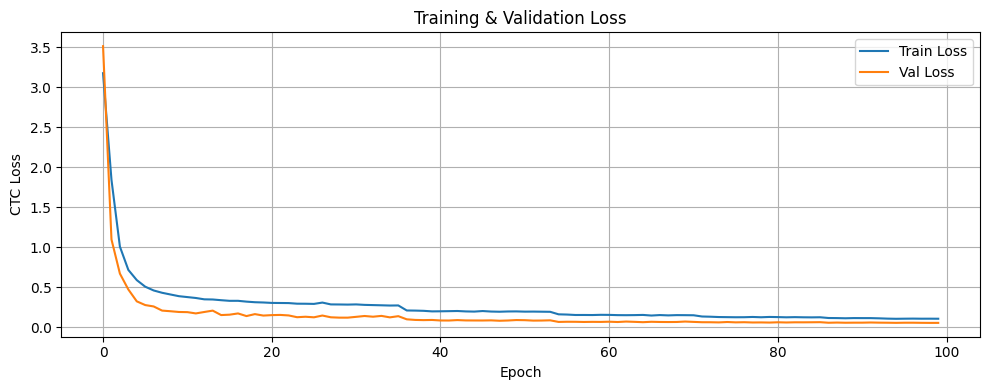

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. Evaluate — Random Samples

In [12]:
# Load best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

print('Predictions on 15 random validation samples:\n')
for _ in range(15):
    idx = random.randint(0, len(val_dataset) - 1)
    img, label = val_dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]

    gt_text = ''.join([idx2char[i.item()] for i in label])
    match = '✓' if pred_text == gt_text else '✗'
    print(f'{match}  GT: {gt_text:20s} | PRED: {pred_text}')

Predictions on 15 random validation samples:

✓  GT: विख्यात              | PRED: विख्यात
✓  GT: दक्षिण               | PRED: दक्षिण
✓  GT: कारण                 | PRED: कारण
✓  GT: चरण                  | PRED: चरण
✓  GT: आश्रम                | PRED: आश्रम
✓  GT: का                   | PRED: का
✓  GT: और                   | PRED: और
✓  GT: अमेरिकी              | PRED: अमेरिकी
✓  GT: पूरी                 | PRED: पूरी
✓  GT: पर                   | PRED: पर
✓  GT: की                   | PRED: की
✓  GT: केवल                 | PRED: केवल
✓  GT: हो                   | PRED: हो
✓  GT: मजदूर                | PRED: मजदूर
✓  GT: के                   | PRED: के


## 8. Visual Predictions

/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/2448026583.py:20: UserWarning: Glyph 2361 (\N{DEVANAGARI LETTER HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/2448026583.py:20: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/2448026583.py:20: UserWarning: Glyph 2376 (\N{DEVANAGARI VOWEL SIGN AI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/2448026583.py:20: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/2448026583.py:20: UserWarning: Glyph 2375 (\N{DEVANAGARI VOWEL SIGN E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43

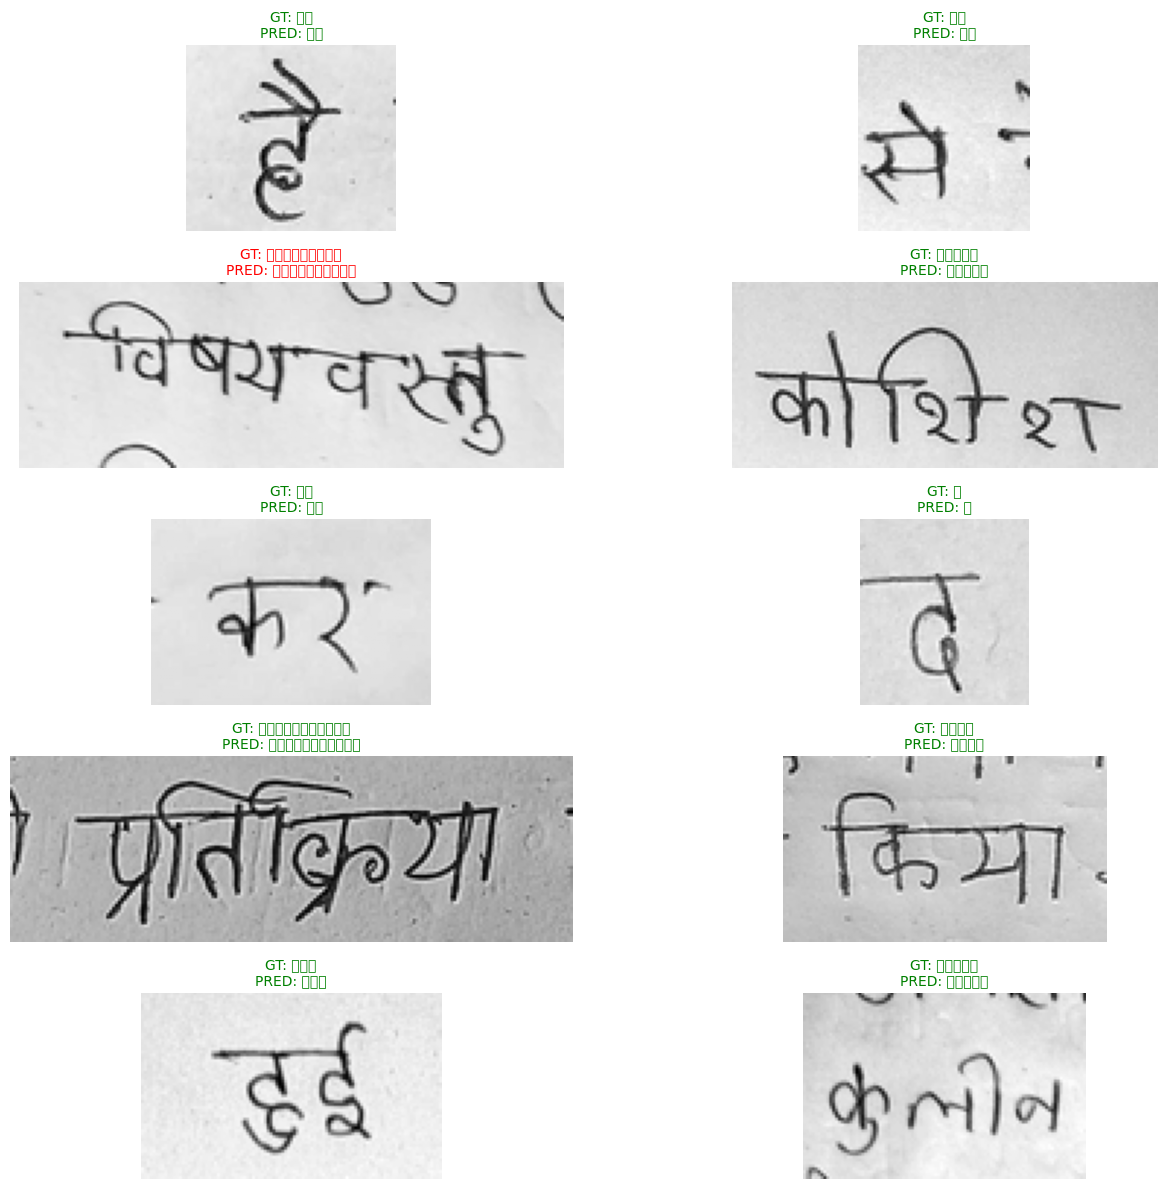

In [13]:
fig, axes = plt.subplots(5, 2, figsize=(14, 12))

for ax in axes.flat:
    idx = random.randint(0, len(val_dataset) - 1)
    img, label = val_dataset[idx]

    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]

    gt_text = ''.join([idx2char[i.item()] for i in label])

    # Denormalize for display
    display_img = img.squeeze().cpu().numpy() * 0.5 + 0.5
    ax.imshow(display_img, cmap='gray')
    color = 'green' if pred_text == gt_text else 'red'
    ax.set_title(f'GT: {gt_text}\nPRED: {pred_text}', fontsize=10, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 9. Accuracy on Validation Set

In [14]:
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for i in range(len(val_dataset)):
        img, label = val_dataset[i]
        pred = model(img.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]
        gt_text = ''.join([idx2char[j.item()] for j in label])
        if pred_text == gt_text:
            correct += 1
        total += 1

print(f'Validation Word Accuracy: {correct}/{total} = {100*correct/total:.2f}%')

Validation Word Accuracy: 8216/8558 = 96.00%


## 10. Visual Inference on Test Set (no labels)

Test set: 20511 images


/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/1381747909.py:35: UserWarning: Glyph 2309 (\N{DEVANAGARI LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/1381747909.py:35: UserWarning: Matplotlib currently does not support Devanagari natively.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/1381747909.py:35: UserWarning: Glyph 2327 (\N{DEVANAGARI LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/1381747909.py:35: UserWarning: Glyph 2360 (\N{DEVANAGARI LETTER SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/1381747909.py:35: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/h8/4rp12f2s01x5nng0h80tjrj40000gn/T/ipykernel_43194/13

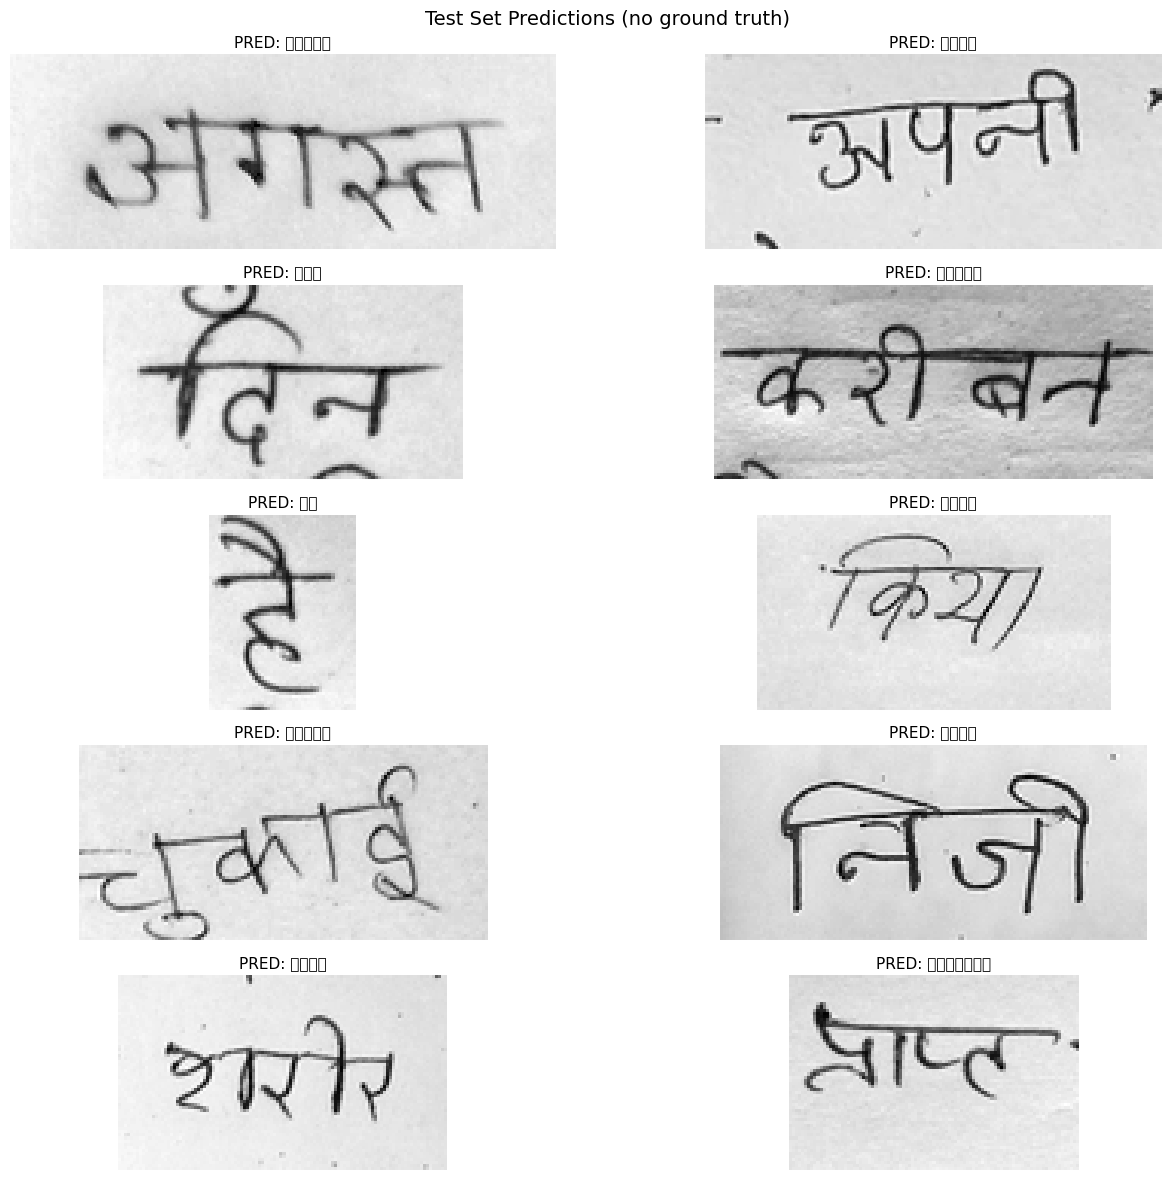

In [15]:
# Load test images (no labels available)
TEST_ROOT = 'Word_Level_Test_Set'
test_image_paths = []
with open(os.path.join(TEST_ROOT, 'test.txt'), 'r', encoding='utf-8') as f:
    for line in f:
        img_rel = line.strip()
        if img_rel:
            test_image_paths.append(img_rel)

print(f'Test set: {len(test_image_paths)} images')

# Show predictions on 10 random test images
model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

fig, axes = plt.subplots(5, 2, figsize=(14, 12))
test_indices = random.sample(range(len(test_image_paths)), 10)

for ax, ti in zip(axes.flat, test_indices):
    img_rel = test_image_paths[ti]
    img_path = os.path.join(TEST_ROOT, img_rel)
    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)

    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]

    display_img = img_t.squeeze().cpu().numpy() * 0.5 + 0.5
    ax.imshow(display_img, cmap='gray')
    ax.set_title(f'PRED: {pred_text}', fontsize=11)
    ax.axis('off')

plt.suptitle('Test Set Predictions (no ground truth)', fontsize=14)
plt.tight_layout()
plt.show()

## 11. Evaluate on Dataset/crops (WER, CER, Accuracy)

In [16]:
# --- Load Dataset/crops with labels.csv (UTF-16, space-separated) ---
def detect_and_read(filepath):
    raw = open(filepath, 'rb').read()
    for enc in ('utf-8-sig', 'utf-8', 'utf-16'):
        try:
            return raw.decode(enc), enc
        except (UnicodeDecodeError, UnicodeError):
            continue
    raise RuntimeError(f'Cannot decode {filepath}')

crops_dir = 'Dataset/crops'
label_file = 'Dataset/labels.csv'
text, enc = detect_and_read(label_file)
print(f'labels.csv encoding: {enc}')

crops_samples = []
skipped_chars = 0
for line in text.strip().split('\n'):
    parts = line.strip().split(' ', 1)
    if len(parts) == 2:
        img_name, label = parts
        label = label.replace('\u200c', '')  # remove ZWNJ
        img_path = os.path.join(crops_dir, img_name)
        if os.path.exists(img_path) and len(label) > 0:
            # Check if all chars are in charset
            valid = True
            for c in label:
                if c not in char2idx:
                    valid = False
                    skipped_chars += 1
                    break
            if valid:
                crops_samples.append((img_path, label))

print(f'Loaded {len(crops_samples)} samples from Dataset/crops (skipped {skipped_chars} with unknown chars)')

# --- Run inference on all samples ---
model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

predictions = []
ground_truths = []

for img_path, gt_label in crops_samples:
    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)

    # Cap width like in training
    if img_t.size(2) > MAX_IMG_WIDTH:
        img_t = img_t[:, :, :MAX_IMG_WIDTH]

    with torch.no_grad():
        pred = model(img_t.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]

    predictions.append(pred_text)
    ground_truths.append(gt_label)

print(f'Inference done on {len(predictions)} samples')

labels.csv encoding: utf-16
Loaded 4148 samples from Dataset/crops (skipped 210 with unknown chars)
Inference done on 4148 samples


In [17]:
# --- Compute WER, CER, and Word Accuracy ---

def edit_distance(s1, s2):
    """Levenshtein distance between two sequences."""
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]


# Word-level accuracy
word_correct = sum(1 for p, g in zip(predictions, ground_truths) if p == g)
word_total = len(predictions)
word_accuracy = 100 * word_correct / word_total

# CER: character error rate = edit_distance(pred_chars, gt_chars) / total_gt_chars
total_char_errors = 0
total_gt_chars = 0
per_sample_cer = []
for pred, gt in zip(predictions, ground_truths):
    char_err = edit_distance(list(pred), list(gt))
    total_char_errors += char_err
    total_gt_chars += len(gt)
    per_sample_cer.append(char_err / max(len(gt), 1))

cer = 100 * total_char_errors / total_gt_chars

# WER: since each sample is a single word, WER = word error rate
# (edit distance on word level = 0 if match, 1 if mismatch)
word_errors = sum(1 for p, g in zip(predictions, ground_truths) if p != g)
wer = 100 * word_errors / word_total

print(f'Dataset/crops Evaluation ({word_total} samples)')
print(f'{"="*45}')
print(f'Word Accuracy:  {word_correct}/{word_total} = {word_accuracy:.2f}%')
print(f'Word Error Rate (WER): {wer:.2f}%')
print(f'Character Error Rate (CER): {cer:.2f}%')
print(f'Total GT characters: {total_gt_chars}')
print(f'Total character errors: {total_char_errors}')

# Per-sample CER distribution
cer_arr = np.array(per_sample_cer)
print(f'\nPer-sample CER distribution:')
print(f'  Mean: {cer_arr.mean()*100:.2f}%')
print(f'  Median: {np.median(cer_arr)*100:.2f}%')
print(f'  Std: {cer_arr.std()*100:.2f}%')
print(f'  Samples with CER=0 (perfect): {(cer_arr == 0).sum()} ({100*(cer_arr == 0).sum()/len(cer_arr):.1f}%)')
print(f'  Samples with CER>50%: {(cer_arr > 0.5).sum()} ({100*(cer_arr > 0.5).sum()/len(cer_arr):.1f}%)')

Dataset/crops Evaluation (4148 samples)
Word Accuracy:  1075/4148 = 25.92%
Word Error Rate (WER): 74.08%
Character Error Rate (CER): 33.23%
Total GT characters: 21350
Total character errors: 7095

Per-sample CER distribution:
  Mean: 38.10%
  Median: 28.57%
  Std: 63.47%
  Samples with CER=0 (perfect): 1075 (25.9%)
  Samples with CER>50%: 925 (22.3%)


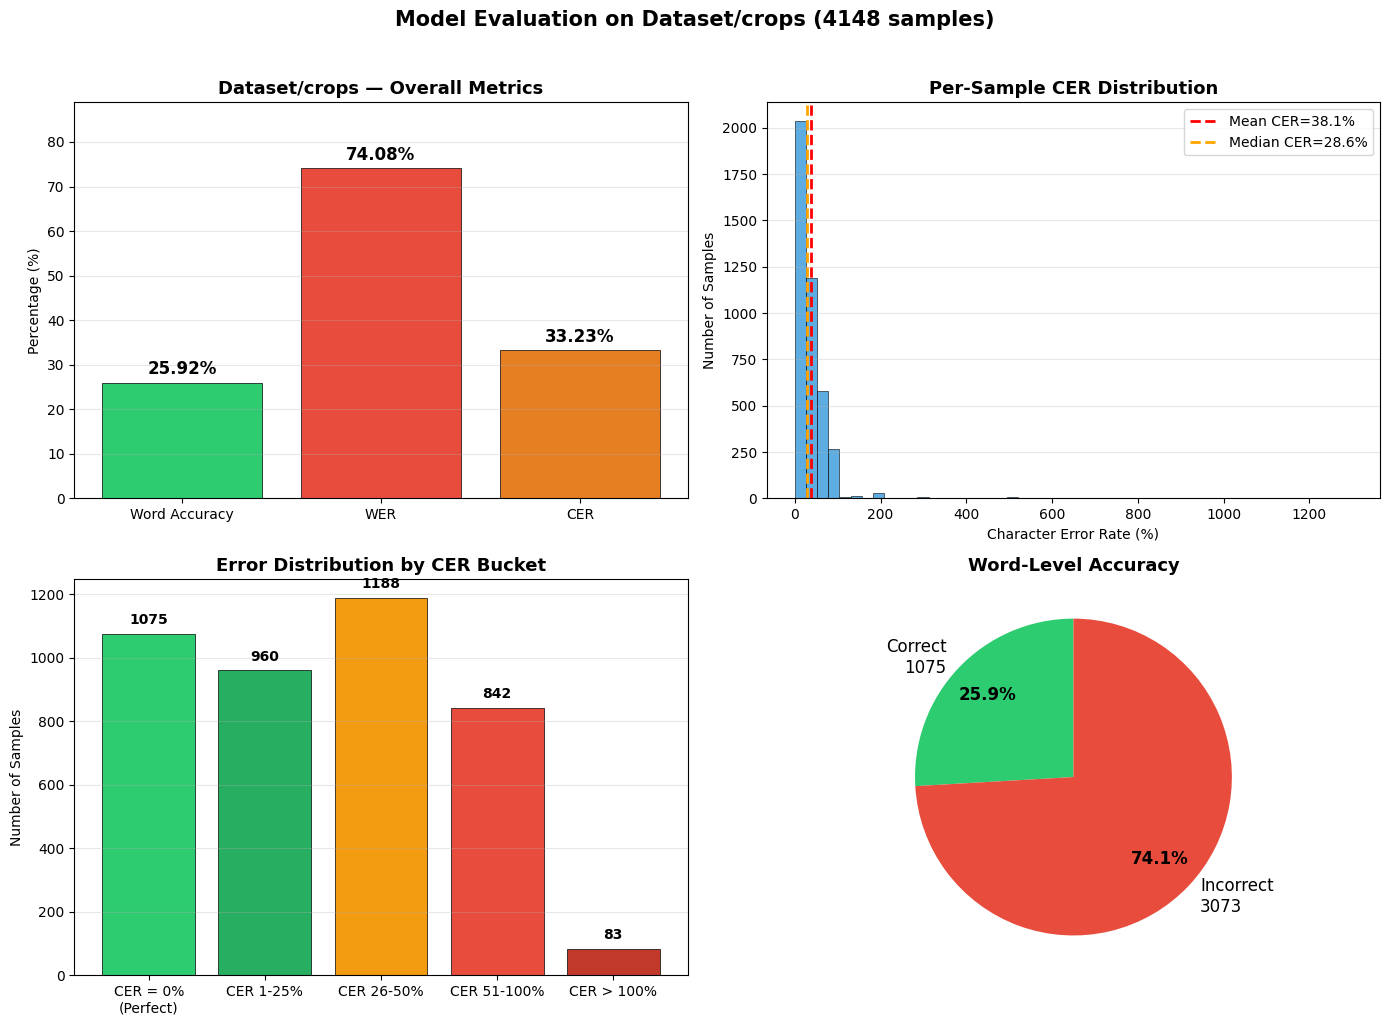

In [18]:
# --- Graphs: WER, CER, Accuracy ---

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Summary bar chart
metrics = ['Word Accuracy', 'WER', 'CER']
values = [word_accuracy, wer, cer]
colors = ['#2ecc71', '#e74c3c', '#e67e22']
ax = axes[0, 0]
bars = ax.bar(metrics, values, color=colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Percentage (%)')
ax.set_title('Dataset/crops — Overall Metrics', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis='y', alpha=0.3)

# 2. CER distribution histogram
ax = axes[0, 1]
ax.hist(cer_arr * 100, bins=50, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(cer_arr.mean() * 100, color='red', linestyle='--', linewidth=2, label=f'Mean CER={cer_arr.mean()*100:.1f}%')
ax.axvline(np.median(cer_arr) * 100, color='orange', linestyle='--', linewidth=2, label=f'Median CER={np.median(cer_arr)*100:.1f}%')
ax.set_xlabel('Character Error Rate (%)')
ax.set_ylabel('Number of Samples')
ax.set_title('Per-Sample CER Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 3. CER buckets (perfect, low, medium, high error)
buckets = ['CER = 0%\n(Perfect)', 'CER 1-25%', 'CER 26-50%', 'CER 51-100%', 'CER > 100%']
bucket_counts = [
    (cer_arr == 0).sum(),
    ((cer_arr > 0) & (cer_arr <= 0.25)).sum(),
    ((cer_arr > 0.25) & (cer_arr <= 0.50)).sum(),
    ((cer_arr > 0.50) & (cer_arr <= 1.0)).sum(),
    (cer_arr > 1.0).sum(),
]
bucket_colors = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
ax = axes[1, 0]
bars = ax.bar(buckets, bucket_counts, color=bucket_colors, edgecolor='black', linewidth=0.5)
for bar, cnt in zip(bars, bucket_counts):
    if cnt > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + word_total*0.005,
                str(int(cnt)), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Number of Samples')
ax.set_title('Error Distribution by CER Bucket', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 4. Correct vs Incorrect pie chart
ax = axes[1, 1]
pie_labels = [f'Correct\n{word_correct}', f'Incorrect\n{word_errors}']
pie_colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax.pie(
    [word_correct, word_errors],
    labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12}, pctdistance=0.75
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Word-Level Accuracy', fontsize=13, fontweight='bold')

plt.suptitle(f'Model Evaluation on Dataset/crops ({word_total} samples)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

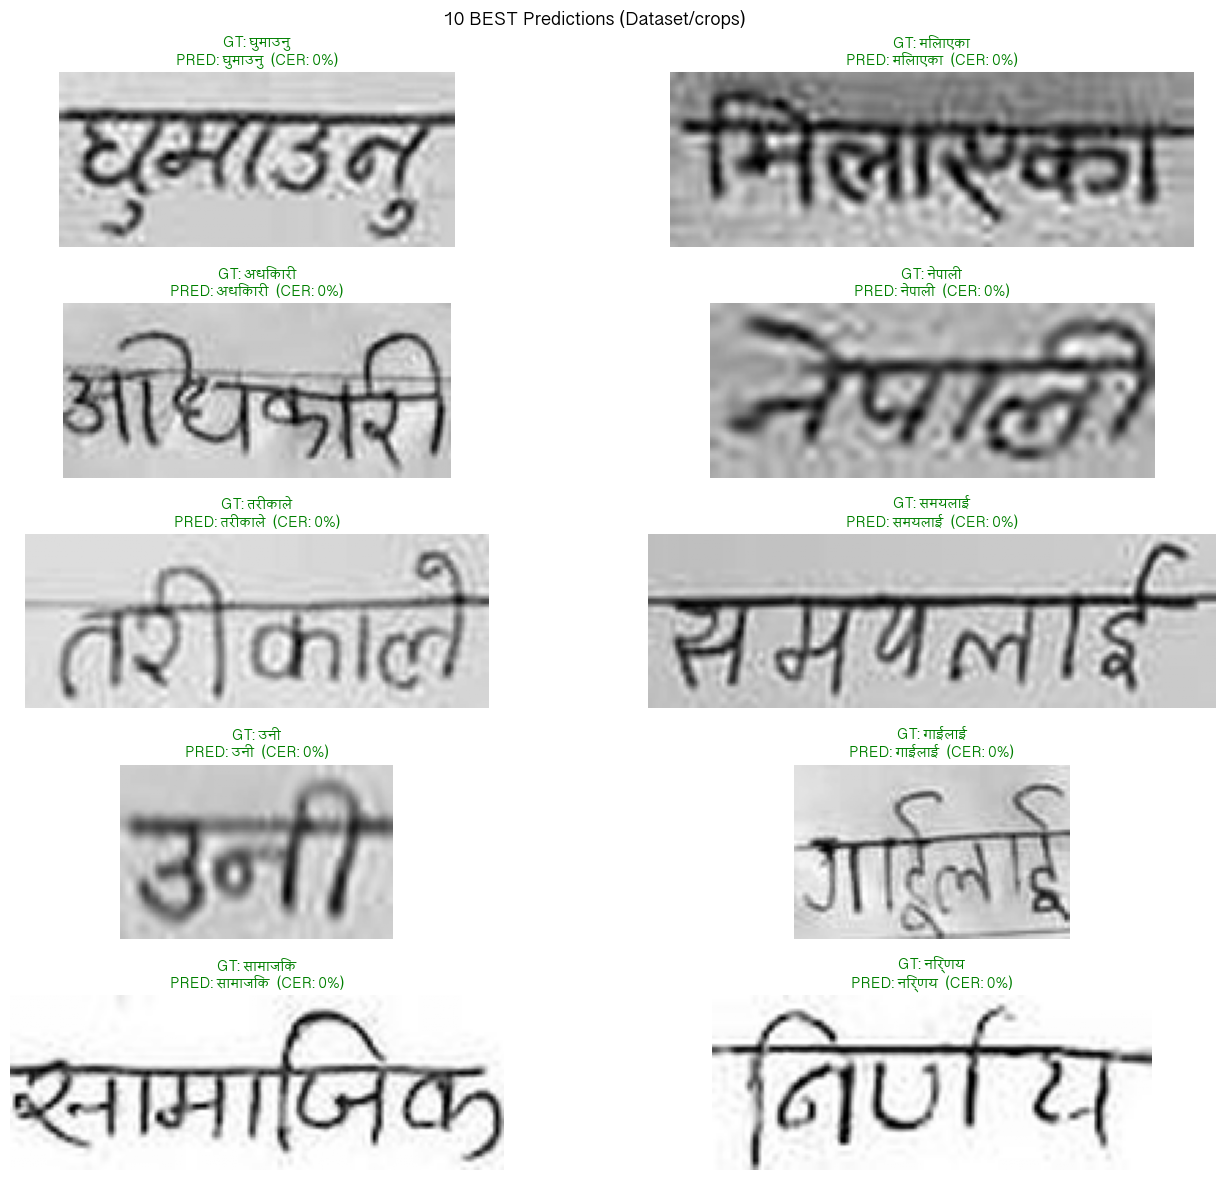

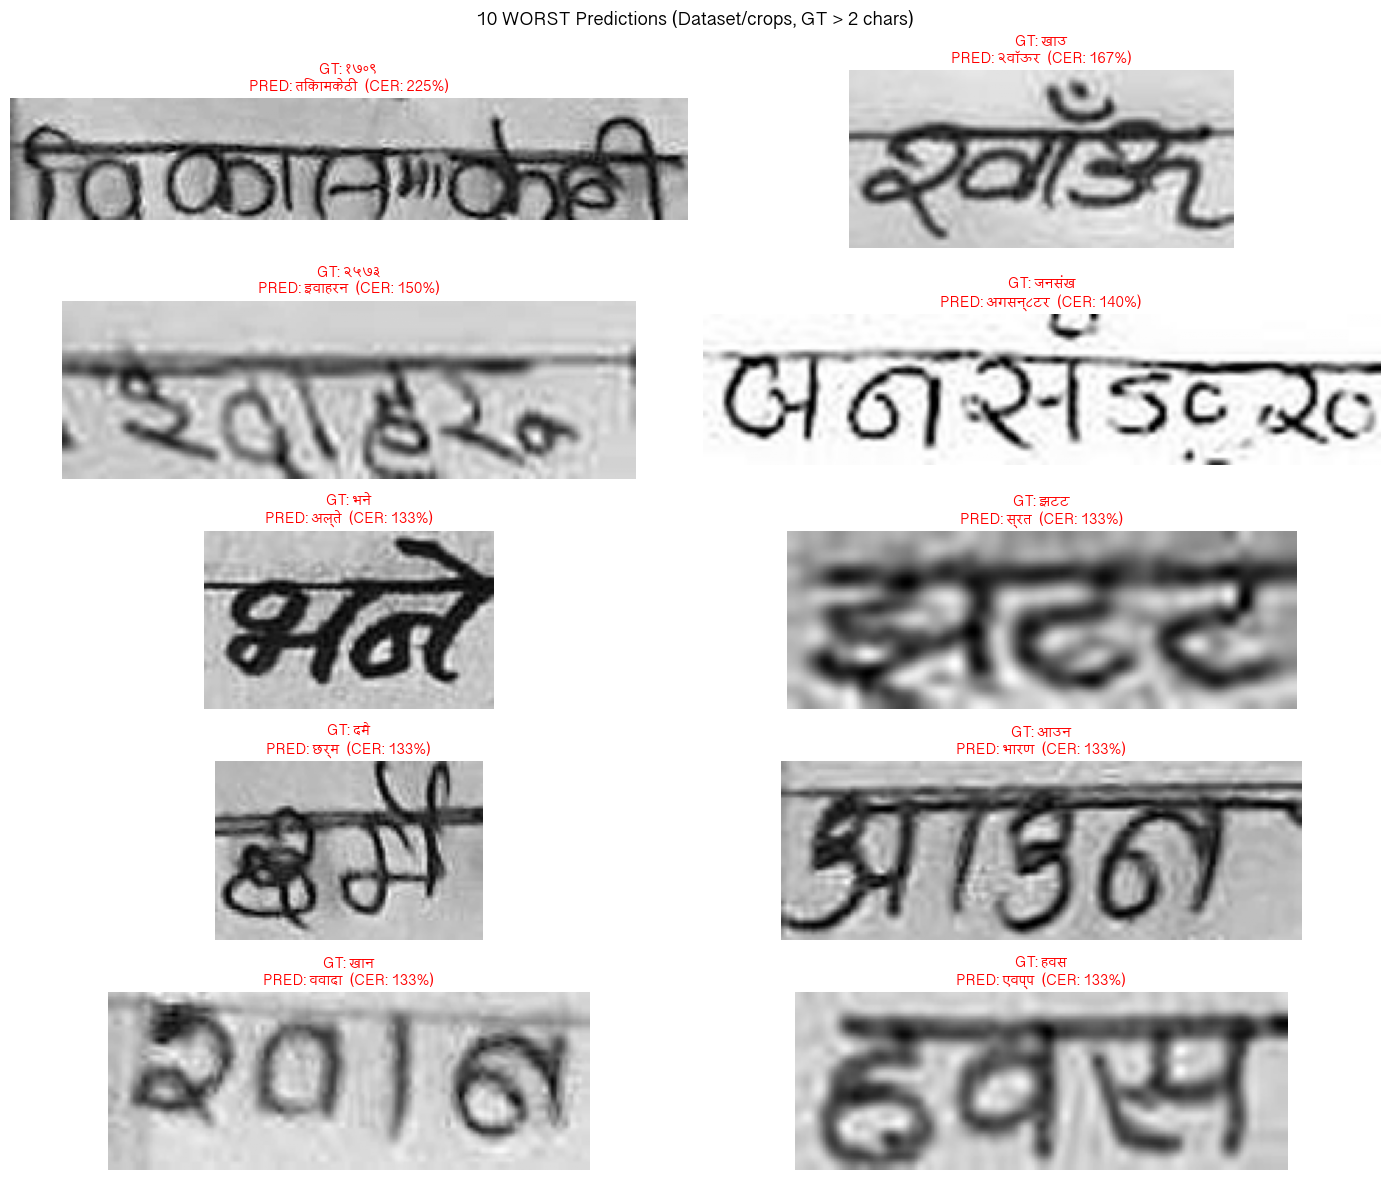

Note: 281 samples have GT with ≤2 chars (e.g. "-") — excluded from worst predictions


In [21]:
# --- Configure Devanagari font for matplotlib ---
from matplotlib import font_manager as fm

deva_font_path = '/System/Library/Fonts/Supplemental/Devanagari Sangam MN.ttc'
deva_prop = fm.FontProperties(fname=deva_font_path, size=11)
deva_prop_title = fm.FontProperties(fname=deva_font_path, size=14)

# Sort samples by CER
indexed_cer = sorted(enumerate(per_sample_cer), key=lambda x: x[1])

# --- 10 BEST predictions (lowest CER) ---
best_indices = [i for i, _ in indexed_cer[:10]]
fig, axes = plt.subplots(5, 2, figsize=(14, 12))

for ax, si in zip(axes.flat, best_indices):
    img_path, gt_label = crops_samples[si]
    pred_text = predictions[si]

    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)
    display_img = img_t.squeeze().cpu().numpy() * 0.5 + 0.5
    ax.imshow(display_img, cmap='gray')

    cer_val = per_sample_cer[si] * 100
    color = 'green' if pred_text == gt_label else 'red'
    title = f'GT: {gt_label}\nPRED: {pred_text}  (CER: {cer_val:.0f}%)'
    ax.set_title(title, fontproperties=deva_prop, color=color)
    ax.axis('off')

fig.suptitle('10 BEST Predictions (Dataset/crops)', fontproperties=deva_prop_title, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 10 WORST predictions (highest CER, excluding trivial GT like "-") ---
# Filter out samples with GT <= 2 chars (mislabeled entries)
worst_candidates = [(i, c) for i, c in indexed_cer if len(ground_truths[i]) > 2]
worst_indices = [i for i, _ in worst_candidates[-10:]]
worst_indices.reverse()  # show worst first

fig, axes = plt.subplots(5, 2, figsize=(14, 12))

for ax, si in zip(axes.flat, worst_indices):
    img_path, gt_label = crops_samples[si]
    pred_text = predictions[si]

    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)
    display_img = img_t.squeeze().cpu().numpy() * 0.5 + 0.5
    ax.imshow(display_img, cmap='gray')

    cer_val = per_sample_cer[si] * 100
    title = f'GT: {gt_label}\nPRED: {pred_text}  (CER: {cer_val:.0f}%)'
    ax.set_title(title, fontproperties=deva_prop, color='red')
    ax.axis('off')

fig.suptitle('10 WORST Predictions (Dataset/crops, GT > 2 chars)', fontproperties=deva_prop_title, fontweight='bold')
plt.tight_layout()
plt.show()

# Count how many samples have trivial GT
trivial = sum(1 for g in ground_truths if len(g) <= 2)
print(f'Note: {trivial} samples have GT with ≤2 chars (e.g. "-") — excluded from worst predictions')

In [ ]:
# --- Save key plots as images for README ---
import os
os.makedirs('assets', exist_ok=True)

from matplotlib import font_manager as fm
deva_font_path = '/System/Library/Fonts/Supplemental/Devanagari Sangam MN.ttc'
deva_prop = fm.FontProperties(fname=deva_font_path, size=11)
deva_prop_title = fm.FontProperties(fname=deva_font_path, size=14)

# 1. Loss curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train Loss')
ax.plot(val_losses, label='Val Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('CTC Loss')
ax.set_title('Training & Validation Loss')
ax.legend(); ax.grid(True)
fig.tight_layout()
fig.savefig('assets/loss_curves.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# 2. Validation predictions grid
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
for ax_i in axes.flat:
    idx = random.randint(0, len(val_dataset) - 1)
    img, label = val_dataset[idx]
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device))
        pred_text = greedy_decoder(pred)[0]
    gt_text = ''.join([idx2char[j.item()] for j in label])
    display_img = img.squeeze().cpu().numpy() * 0.5 + 0.5
    ax_i.imshow(display_img, cmap='gray')
    color = 'green' if pred_text == gt_text else 'red'
    ax_i.set_title(f'GT: {gt_text}\nPRED: {pred_text}', fontproperties=deva_prop, color=color)
    ax_i.axis('off')
fig.suptitle('Validation Set Predictions (96% Accuracy)', fontproperties=deva_prop_title, fontweight='bold')
fig.tight_layout()
fig.savefig('assets/val_predictions.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# 3. Evaluation metrics (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax = axes[0, 0]
m_names = ['Word Accuracy', 'WER', 'CER']
m_vals = [word_accuracy, wer, cer]
m_cols = ['#2ecc71', '#e74c3c', '#e67e22']
bars = ax.bar(m_names, m_vals, color=m_cols, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, m_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Percentage (%)'); ax.set_title('Dataset/crops — Overall Metrics', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(m_vals) * 1.2); ax.grid(axis='y', alpha=0.3)

ax = axes[0, 1]
ax.hist(cer_arr * 100, bins=50, color='#3498db', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(cer_arr.mean() * 100, color='red', linestyle='--', linewidth=2, label=f'Mean CER={cer_arr.mean()*100:.1f}%')
ax.axvline(np.median(cer_arr) * 100, color='orange', linestyle='--', linewidth=2, label=f'Median CER={np.median(cer_arr)*100:.1f}%')
ax.set_xlabel('Character Error Rate (%)'); ax.set_ylabel('Number of Samples')
ax.set_title('Per-Sample CER Distribution', fontsize=13, fontweight='bold'); ax.legend(); ax.grid(axis='y', alpha=0.3)

bkt = ['CER = 0%\n(Perfect)', 'CER 1-25%', 'CER 26-50%', 'CER 51-100%', 'CER > 100%']
bkt_c = [(cer_arr == 0).sum(), ((cer_arr > 0) & (cer_arr <= 0.25)).sum(), ((cer_arr > 0.25) & (cer_arr <= 0.50)).sum(), ((cer_arr > 0.50) & (cer_arr <= 1.0)).sum(), (cer_arr > 1.0).sum()]
bkt_cols = ['#2ecc71', '#27ae60', '#f39c12', '#e74c3c', '#c0392b']
ax = axes[1, 0]
bars = ax.bar(bkt, bkt_c, color=bkt_cols, edgecolor='black', linewidth=0.5)
for bar, cnt in zip(bars, bkt_c):
    if cnt > 0: ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + word_total*0.005, str(int(cnt)), ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Number of Samples'); ax.set_title('Error Distribution by CER Bucket', fontsize=13, fontweight='bold'); ax.grid(axis='y', alpha=0.3)

ax = axes[1, 1]
wedges, texts, autotexts = ax.pie([word_correct, word_errors], labels=[f'Correct\n{word_correct}', f'Incorrect\n{word_errors}'], colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12}, pctdistance=0.75)
for t in autotexts: t.set_fontweight('bold')
ax.set_title('Word-Level Accuracy', fontsize=13, fontweight='bold')
fig.suptitle(f'Model Evaluation on Dataset/crops ({word_total} samples)', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('assets/eval_metrics.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# 4. Best predictions
best_indices_r = [i for i, _ in indexed_cer[:10]]
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
for ax_i, si in zip(axes.flat, best_indices_r):
    img_path, gt_label = crops_samples[si]
    pred_text = predictions[si]
    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)
    display_img = img_t.squeeze().cpu().numpy() * 0.5 + 0.5
    ax_i.imshow(display_img, cmap='gray')
    cer_val = per_sample_cer[si] * 100
    ax_i.set_title(f'GT: {gt_label}\nPRED: {pred_text}  (CER: {cer_val:.0f}%)', fontproperties=deva_prop, color='green')
    ax_i.axis('off')
fig.suptitle('Best Predictions on Dataset/crops (CER = 0%)', fontproperties=deva_prop_title, fontweight='bold')
fig.tight_layout()
fig.savefig('assets/best_predictions.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# 5. Worst predictions
worst_cands = [(i, c) for i, c in indexed_cer if len(ground_truths[i]) > 2]
worst_idx_r = [i for i, _ in worst_cands[-10:]]
worst_idx_r.reverse()
fig, axes = plt.subplots(5, 2, figsize=(14, 12))
for ax_i, si in zip(axes.flat, worst_idx_r):
    img_path, gt_label = crops_samples[si]
    pred_text = predictions[si]
    img = Image.open(img_path).convert('L')
    img_t = val_transform(img)
    display_img = img_t.squeeze().cpu().numpy() * 0.5 + 0.5
    ax_i.imshow(display_img, cmap='gray')
    cer_val = per_sample_cer[si] * 100
    ax_i.set_title(f'GT: {gt_label}\nPRED: {pred_text}  (CER: {cer_val:.0f}%)', fontproperties=deva_prop, color='red')
    ax_i.axis('off')
fig.suptitle('Worst Predictions on Dataset/crops', fontproperties=deva_prop_title, fontweight='bold')
fig.tight_layout()
fig.savefig('assets/worst_predictions.png', dpi=150, bbox_inches='tight')
plt.close(fig)

# 6. Architecture diagram (text-based)
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
blocks = ['Input\n(1×64×W)', 'VGG\nFeatureExtractor', 'AdaptiveAvgPool\n+ Dropout(0.3)', 'BiLSTM ×2\n(256 hidden)', 'Dropout(0.3)', 'Linear\n(256→101)', 'CTC\nDecoder']
cols = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
for j, (b, col) in enumerate(zip(blocks, cols)):
    x = j * 1.5
    ax.add_patch(plt.Rectangle((x, 0), 1.2, 0.8, facecolor=col, edgecolor='black', linewidth=1.5, alpha=0.85))
    ax.text(x + 0.6, 0.4, b, ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    if j < len(blocks) - 1:
        ax.annotate('', xy=(x + 1.5, 0.4), xytext=(x + 1.2, 0.4), arrowprops=dict(arrowstyle='->', lw=2))
ax.set_xlim(-0.2, len(blocks) * 1.5); ax.set_ylim(-0.3, 1.1)
ax.set_title('CRNN Architecture', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig('assets/architecture.png', dpi=150, bbox_inches='tight')
plt.close(fig)

print('Saved all plots to assets/')

Saved all plots to assets/


: 

## Test Set Predictions (Word_Level_Test_Set — No Ground Truth)

Chars: 100, Classes: 101
Model loaded.
Total test images: 20511
image/61017_9.jpg -> नायक
image/45542_14.jpg -> के
image/66875_2.jpg -> खवरीद
image/47113_26.jpg -> देते
image/51790_13.jpg -> से
image/52475_9.jpg -> काल
image/46853_13.jpg -> से
image/63589_18.jpg -> करने
image/64257_27.jpg -> अगले
image/62529_23.jpg -> से
image/42692_8.jpg -> वितरण
image/52193_16.jpg -> का
image/10851_24.jpg -> विभाग
image/45081_16.jpg -> दिन
image/52378_9.jpg -> उस
image/20213_16.jpg -> पर
image/53623_22.jpg -> मदद
image/79186_12.jpg -> से
image/45918_15.jpg -> पर
image/31792_8.jpg -> वाली

Predicted 20 test samples.


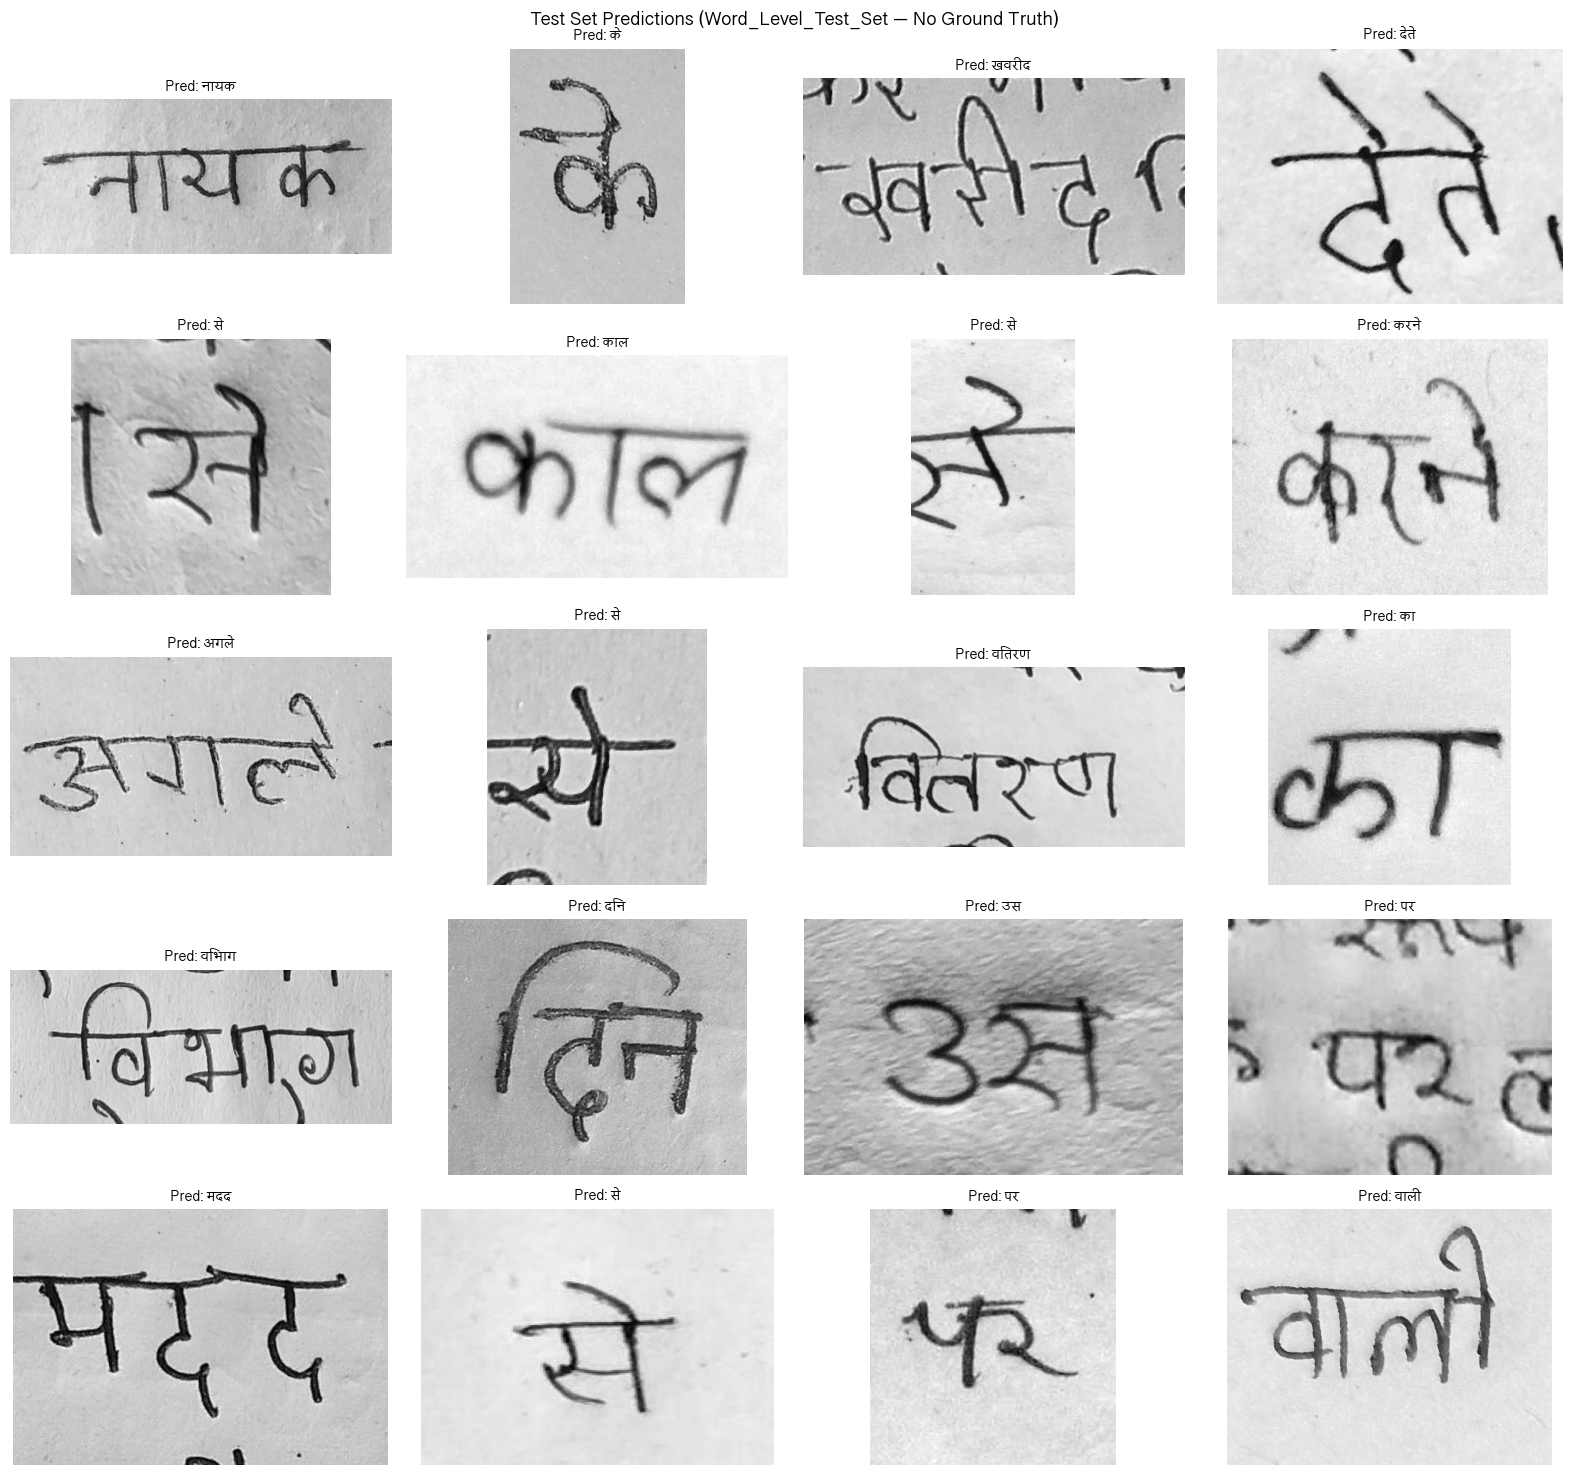

Saved to assets/test_set_predictions.png


In [6]:
import torch
import torch.nn as nn
import os
import random
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager as fm

# --- Device ---
device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

# --- Character set from nepali_char.txt ---
CHAR_FILE = 'exported_model/nepali_char.txt'
with open(CHAR_FILE, 'r', encoding='utf-8') as f:
    CHARS = [line.rstrip('\n') for line in f]
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES = len(CHARS) + 1
print(f'Chars: {len(CHARS)}, Classes: {NUM_CLASSES}')

# --- Model architecture (EasyOCR-style, matches saved weights) ---
class BidirectionalLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.rnn = nn.LSTM(input_size, hidden_size, bidirectional=True, batch_first=True)
        self.linear = nn.Linear(hidden_size * 2, output_size)
    def forward(self, x):
        try: self.rnn.flatten_parameters()
        except: pass
        rec, _ = self.rnn(x)
        return self.linear(rec)

class VGG_FeatureExtractor(nn.Module):
    def __init__(self, input_channel, output_channel=256):
        super().__init__()
        oc = [output_channel // 8, output_channel // 4, output_channel // 2, output_channel]
        self.ConvNet = nn.Sequential(
            nn.Conv2d(input_channel, oc[0], 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(oc[0], oc[1], 3, 1, 1), nn.ReLU(True), nn.MaxPool2d(2, 2),
            nn.Conv2d(oc[1], oc[2], 3, 1, 1), nn.ReLU(True),
            nn.Conv2d(oc[2], oc[2], 3, 1, 1), nn.ReLU(True), nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(oc[2], oc[3], 3, 1, 1, bias=False), nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.Conv2d(oc[3], oc[3], 3, 1, 1, bias=False), nn.BatchNorm2d(oc[3]), nn.ReLU(True),
            nn.MaxPool2d((2,1),(2,1)),
            nn.Conv2d(oc[3], oc[3], 2, 1, 0), nn.ReLU(True),
        )
    def forward(self, x):
        return self.ConvNet(x)

class CRNN(nn.Module):
    def __init__(self, input_channel=1, output_channel=256, hidden_size=256,
                 num_class=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.FeatureExtraction = VGG_FeatureExtractor(input_channel, output_channel)
        self.FeatureExtraction_output = output_channel
        self.AdaptiveAvgPool = nn.AdaptiveAvgPool2d((None, 1))
        self.dropout = nn.Dropout(dropout)
        self.SequenceModeling = nn.Sequential(
            BidirectionalLSTM(output_channel, hidden_size, hidden_size),
            BidirectionalLSTM(hidden_size, hidden_size, hidden_size),
        )
        self.Prediction = nn.Linear(hidden_size, num_class)

    def forward(self, x):
        feat = self.FeatureExtraction(x)
        feat = self.AdaptiveAvgPool(feat.permute(0, 3, 1, 2)).squeeze(3)
        feat = self.dropout(feat)
        seq = self.SequenceModeling(feat)
        seq = self.dropout(seq)
        pred = self.Prediction(seq.contiguous())
        return pred.permute(1, 0, 2)  # [T, B, C]

def greedy_decoder(output):
    output = output.softmax(2)
    max_indices = output.argmax(2).permute(1, 0)
    decoded = []
    for indices in max_indices:
        s, prev = '', 0
        for i in indices:
            idx = i.item()
            if idx != prev and idx != 0 and idx in idx2char:
                s += idx2char[idx]
            prev = idx
        decoded.append(s)
    return decoded

# --- Load model ---
model = CRNN().to(device)
model.load_state_dict(torch.load('exported_model/nepali_crnn_best.pth', map_location=device, weights_only=True))
model.eval()
print('Model loaded.')

# --- Read test file list ---
test_dir = 'Word_Level_Test_Set'
with open(os.path.join(test_dir, 'test.txt'), 'r') as f:
    test_files = [line.strip() for line in f if line.strip()]
print(f'Total test images: {len(test_files)}')

# --- Preprocessing ---
IMG_HEIGHT = 64
MAX_IMG_WIDTH = 600

class ResizeKeepAspectRatio:
    def __init__(self, height):
        self.height = height
    def __call__(self, img):
        w, h = img.size
        new_w = max(1, int(w * (self.height / h)))
        return img.resize((new_w, self.height), Image.LANCZOS)

test_transform = transforms.Compose([
    ResizeKeepAspectRatio(IMG_HEIGHT),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# --- Pick 20 random samples and run inference ---
random.seed(123)
sample_files = random.sample(test_files, 20)

results = []
for fname in sample_files:
    img_path = os.path.join(test_dir, fname)
    try:
        img = Image.open(img_path).convert('L')
    except Exception as e:
        print(f'Skipping {fname}: {e}')
        continue

    img_t = test_transform(img).unsqueeze(0).to(device)
    # Cap width
    if img_t.size(3) > MAX_IMG_WIDTH:
        img_t = img_t[:, :, :, :MAX_IMG_WIDTH]

    with torch.no_grad():
        pred = model(img_t)
        pred_text = greedy_decoder(pred)[0]

    results.append((fname, img, pred_text))
    print(f'{fname} -> {pred_text}')

print(f'\nPredicted {len(results)} test samples.')

# --- Plot 20 predictions in a 5x4 grid ---
deva_font_path = '/System/Library/Fonts/Supplemental/Devanagari Sangam MN.ttc'
deva_prop = fm.FontProperties(fname=deva_font_path, size=11)
deva_prop_title = fm.FontProperties(fname=deva_font_path, size=14)

fig, axes = plt.subplots(5, 4, figsize=(16, 15))
fig.suptitle('Test Set Predictions (Word_Level_Test_Set — No Ground Truth)',
             fontproperties=deva_prop_title, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(results):
        fname, img, pred_text = results[i]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Pred: {pred_text}', fontproperties=deva_prop, fontsize=11)
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/test_set_predictions.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved to assets/test_set_predictions.png')